<a href="https://colab.research.google.com/github/ljm0616/Capstone_project/blob/main/%EB%B0%98%EB%8F%84%EC%B2%B4_%EA%B3%B5%EC%A0%95%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D%EC%8B%A4%EC%8A%B5_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 반도체 공정 데이터 분석 — 불량 신호 탐색과 룰베이스 분류

## 파일 사용법

이 노트북은 ChatGPT가 코드를 **작성하고 직접 실행**한 뒤, 같은 코드를 Colab에서도 실행해 결과를 확인하는 방식으로 사용한다.

1. 새 ChatGPT 대화를 열고 `반도체_공정데이터_전체.csv`와 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 함께 첨부한다.
2. 아래의 **새 ChatGPT 대화 시작 프롬프트**를 한 번 입력한다.
3. 각 과제의 첫 번째 프롬프트를 입력한다.
4. ChatGPT가 제시하고 직접 실행한 코드를 해당 Colab 코드 셀에 복사해 실행한 뒤 두 결과를 비교한다.
5. 같은 ChatGPT 대화에서 해당 과제의 다음 프롬프트를 입력한다.
6. ChatGPT가 작성한 해석을 해당 과제의 Colab 마크다운 셀에 복사해 넣는다.

ChatGPT가 같은 대화에서 직접 만든 표와 그래프를 보고 있으므로, Colab 결과가 동일하다면 화면을 다시 첨부하지 않는다. 코드를 수정했거나 두 환경의 결과가 다를 때만 Colab 화면을 첨부한다.

## 그래프 한글 표기

- **ChatGPT:** 함께 첨부한 wheel 파일을 대화의 Python 환경에 설치한다.
- **Colab:** 환경 준비 셀에서 PyPI의 `koreanize-matplotlib`을 설치한다.
- 두 환경 모두 이후 분석·시각화 코드에서 한글 제목과 축 이름을 사용한다.

## 분석 시나리오

반도체 생산 공정에서 수집한 웨이퍼별 공정 지표와 최종 검사 결과를 분석한다. 어떤 공정 변수에서 `Pass`와 `Fail`의 분포 차이가 나타나는지 찾고, 이해하기 쉬운 세 가지 룰을 단계적으로 결합하여 불량 웨이퍼를 어느 정도 선별할 수 있는지 확인한다.

학생 실습은 데이터 파악, 시각화 탐색, 핵심 변수 심화 분석, 인사이트 정리, 룰 도출 및 검증 순으로 진행한다. 이 실습에서 양성 클래스는 **Fail**이며, Precision과 Recall도 Fail을 기준으로 계산한다.

- 파일: `반도체_공정데이터_전체.csv` (728행, 32개 컬럼)
- 식별자: `wafer_id`
- 타겟: `inspection_result` (`Pass` / `Fail`)
- 입력 변수: 30개의 수치형 공정 지표

> **주의:** 변수명은 공정 단계와 측정 항목을 나타내지만 물리 단위는 별도로 제공되지 않았다. 값의 절대적인 공학적 의미를 추정하지 않고, 이 데이터 안에서 나타나는 상대적 분포와 분류 신호를 중심으로 해석한다.


## 새 ChatGPT 대화 시작 프롬프트

`반도체_공정데이터_전체.csv`와 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 함께 첨부한 새 대화에서 아래 내용을 처음부터 끝까지 한 번 입력한다. 프롬프트 본문은 복사하기 쉽도록 코드 블록으로 감싸지 않았다.

첨부한 `반도체_공정데이터_전체.csv`로 Python 데이터 분석 실습을 진행하겠습니다. 한글 그래프를 위해 함께 첨부한 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 사용하세요. 앞으로 분석 작업을 하나씩 요청할 테니 다음 기준을 계속 지켜 주세요.

- 요청한 작업만 수행하고 이후 분석을 미리 진행하지 마세요.
- 코드 작성을 요청하면 Colab 코드 셀에 바로 붙여 넣을 수 있는 해당 과제의 전체 Python 코드를 먼저 제시한 다음, 같은 코드를 ChatGPT의 데이터 분석 환경에서 직접 실행하여 지정한 결과를 보여 주세요.
- 코드 실행 단계에서는 결과를 해석하거나 다음 분석을 진행하지 마세요.
- 결과 해석을 요청하면 해당 과제에서 이 대화로 직접 실행해 확인한 결과만 근거로 사용하세요.
- 결과 해석 단계에서는 새로운 계산이나 그래프 작성, 다음 단계 분석을 진행하지 마세요.
- 해석은 Colab 마크다운 셀에 그대로 붙여 넣을 수 있는 일반 마크다운 본문으로 작성하고 마크다운 코드 블록으로 감싸지 마세요.
- 지정한 출력이나 해석을 완료하면 추가 작업을 제안하지 말고 멈춰서 다음 요청을 기다리세요.
- 앞선 요청에서 만든 `df`, `불량값`, `signal_cols`, `rule1` 등의 변수와 분석 환경은 같은 대화에서 계속 사용하세요.
- 초보자가 이해하기 쉬운 일반적인 코드를 사용하고 지나치게 압축하거나 복잡한 방법은 피하세요.
- 데이터를 변경하라는 요청이 없다면 원본 데이터프레임을 임의로 수정하지 마세요.
- 그래프의 제목·축·범례는 한글로 작성하세요.
- `inspection_result`에서 `Fail`을 양성 클래스 1, `Pass`를 음성 클래스 0으로 사용하세요.

먼저 다음 초기화 코드를 그대로 직접 실행하세요. 분석은 시작하지 말고, 실행이 끝나면 `한글 그래프 설정 완료`와 `준비되었습니다.`만 출력한 뒤 멈추세요.

```python
import sys
import subprocess
from pathlib import Path

search_roots = [Path('/mnt/data'), Path.cwd()]
wheel_files = []
for root in search_roots:
    if root.exists():
        wheel_files.extend(root.rglob('koreanize_matplotlib-*.whl'))

if not wheel_files:
    raise FileNotFoundError(
        '첨부한 koreanize_matplotlib wheel 파일을 찾을 수 없습니다.'
    )

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', str(wheel_files[0])],
    check=True
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

sns.set_theme(style='whitegrid')
koreanize_matplotlib.koreanize()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
print('한글 그래프 설정 완료')
print('준비되었습니다.')
```


## 0. Colab 환경 준비

아래 두 코드 셀을 순서대로 실행한다. 첫 번째 셀은 `koreanize-matplotlib`을 설치하고, 두 번째 셀은 분석 라이브러리와 한글 그래프 설정을 불러온다. 런타임을 새로 시작한 경우 두 셀을 다시 실행한다.


In [ ]:
import sys
import subprocess

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'],
    check=True
)
print('koreanize-matplotlib 설치 완료')


koreanize-matplotlib 설치 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from pathlib import Path

sns.set_theme(style='whitegrid')
koreanize_matplotlib.koreanize()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
print('한글 그래프 설정 완료')


한글 그래프 설정 완료


---
## 1. 데이터 파악


### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.


**Prompt**

첨부한 `반도체_공정데이터_전체.csv`를 판다스로 불러와 `df`에 저장하고, 사용한 파일명과 데이터 크기, 처음 5행을 확인하는 코드를 작성해 주세요. 파일명 뒤에 `(1)` 같은 숫자가 붙어 있어도 찾을 수 있게 해 주세요.


In [ ]:
# 여기 AI의 코드 붙여넣기
from pathlib import Path
import pandas as pd

search_roots = [Path('/mnt/data'), Path.cwd()]
csv_files = []

for root in search_roots:
    if root.exists():
        csv_files.extend(root.glob('반도체_공정데이터_전체*.csv'))

if not csv_files:
    raise FileNotFoundError(
        '반도체_공정데이터_전체.csv 파일을 찾을 수 없습니다.'
    )

file_path = csv_files[0]

df = pd.read_csv(file_path)

print('사용한 파일명:', file_path.name)
print('데이터 크기:', df.shape)
display(df.head())




사용한 파일명: 반도체_공정데이터_전체.csv
데이터 크기: (728, 32)


,wafer_id,etch_chamber_temp_avg,cmp_endpoint_thickness,thermal_anneal_temp_max,etch_endpoint_signal,wafer_edge_exclusion,etch_pressure_peak,cmp_pad_temp,deposition_uniformity_index,deposition_thickness_var,cleaning_dhf_concentration,deposition_rate_mean,implant_dose_total,litho_overlay_y,etch_chamber_temp_std,deposition_gas_flow_avg,litho_overlay_x,metrology_cd_mean,cmp_slurry_flow_rate,implant_beam_current,metrology_cd_uniformity,etch_rf_power_mean,cmp_polish_time,litho_exposure_time,deposition_chamber_pressure,litho_dose_avg,implant_tilt_angle,implant_energy_mean,cmp_pressure_avg,particle_count_post,litho_focus_offset,inspection_result
0,WH_0000,2.2300,17.7700,10.1066,66.4333,57.6641,-5333.75,11.3429,0.0492,NaN,1.8000,0.6304,15.74,6.34615,55.4572,3.5690,8.1584,0.0,1.4391,3.12,0.0192,-3.5430,4.1872,0.103,0.0755,0.0295,5.3530,1.7350,15.65,221.4286,-0.0085,Pass
1,WH_0001,0.8764,NaN,4.9259,69.3333,902.0772,0.00,0.0000,0.0000,8.7696,3.3099,0.7713,15.91,6.34615,60.1367,NaN,0.0000,NaN,0.0000,19.90,0.0254,1.9390,0.0000,0.000,0.1004,0.0295,6.5683,0.9791,15.93,52.4656,-0.0110,Pass
2,WH_0002,27.4627,12.5373,5.4171,72.8222,529.3532,-6312.25,7.6993,0.0460,9.3998,3.2042,0.6518,15.82,6.75350,NaN,21.9603,11.3706,0.0,1.8363,6.76,0.0533,NaN,4.3765,0.112,0.2177,0.0315,5.8049,1.3800,15.88,410.1695,-0.0100,Pass
3,WH_0003,-2.8555,22.8555,6.7199,NaN,0.0000,-6476.25,NaN,0.0344,NaN,2.0083,NaN,15.51,NaN,51.3761,5.6831,7.2993,0.0,6.7630,5.02,0.0279,-1.2770,2.8420,0.080,0.0956,0.0295,5.6773,1.1020,15.47,767.4074,-0.0109,Pass
4,WH_0004,-2.0836,22.0836,13.9342,NaN,229.3217,NaN,6.4235,0.0466,8.7568,3.8979,0.7611,15.90,2.64820,35.6627,8.4789,7.9365,0.0,1.1425,7.32,0.0182,0.4258,NaN,0.100,NaN,0.0123,NaN,0.9838,15.95,134.6375,-0.0104,Pass


**Prompt**

데이터의 크기, 한 행이 나타내는 대상, 식별자와 타겟 컬럼을 3문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>
데이터는 728행 × 32열로 구성되어 있으며, 한 행은 하나의 웨이퍼(반도체 공정 대상)에 대한 공정·검사 정보를 나타냅니다.
식별자 컬럼은 wafer_id, 타겟 컬럼은 검사 결과를 나타내는 **inspection_result**입니다.



### 과제 1-2. 각 컬럼의 자료형과 결측치를 확인하시오.


**Prompt**

현재 `df`의 각 컬럼명과 자료형, 결측치 수, 결측률을 하나의 표로 출력하는 판다스 코드를 작성해 주세요. 결측치가 많은 컬럼부터 정렬하고 결측률은 소수점 첫째 자리까지 표시해 주세요.


In [ ]:
missing_table = pd.DataFrame({
    '컬럼명': df.columns,
    '자료형': df.dtypes.astype(str).values,
    '결측치 수': df.isnull().sum().values,
    '결측률(%)': (df.isnull().mean() * 100).round(1).values
})

missing_table = missing_table.sort_values(
    by='결측치 수',
    ascending=False
).reset_index(drop=True)

print(missing_table.to_string(index=False))

                        컬럼명     자료형  결측치 수  결측률(%)
   deposition_thickness_var float64     71     9.8
    thermal_anneal_temp_max float64     69     9.5
          metrology_cd_mean float64     69     9.5
       wafer_edge_exclusion float64     68     9.3
    deposition_gas_flow_avg float64     67     9.2
            litho_overlay_y float64     66     9.1
         implant_tilt_angle float64     66     9.1
 cleaning_dhf_concentration float64     63     8.7
     cmp_endpoint_thickness float64     63     8.7
       etch_endpoint_signal float64     61     8.4
    metrology_cd_uniformity float64     60     8.2
            cmp_polish_time float64     59     8.1
            litho_overlay_x float64     57     7.8
      etch_chamber_temp_std float64     53     7.3
deposition_chamber_pressure float64     52     7.1
         implant_dose_total float64     51     7.0
       implant_beam_current float64     51     7.0
        litho_exposure_time float64     50     6.9
         etch_pressure_peak flo

**Prompt**

수치형·범주형 컬럼 구성을 구분하고, 결측치가 가장 많은 컬럼과 가장 적은 수치형 컬럼, 전체 결측치 수를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>
전체 32개 컬럼 중 수치형 컬럼은 30개(float64), **범주형 컬럼은 2개(object: wafer_id, inspection_result)**입니다.
결측치가 가장 많은 컬럼은 **deposition_thickness_var로 71개(9.8%)**입니다.
수치형 컬럼 중 결측치가 가장 적은 컬럼은 **litho_focus_offset으로 37개(5.1%)**입니다.
전체 결측치 수는 1,617개입니다.

### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.


**Prompt**

현재 `df`에서 수치형 컬럼만 선택해 개수, 평균, 표준편차, 최솟값, 사분위수와 최댓값을 확인하는 코드를 작성해 주세요. 결과는 소수점 넷째 자리까지 표시해 주세요.


In [ ]:
numeric_df = df.select_dtypes(include='number')

summary_stats = numeric_df.describe().round(4)

print(summary_stats.to_string())

       etch_chamber_temp_avg  cmp_endpoint_thickness  thermal_anneal_temp_max  etch_endpoint_signal  wafer_edge_exclusion  etch_pressure_peak  cmp_pad_temp  deposition_uniformity_index  deposition_thickness_var  cleaning_dhf_concentration  deposition_rate_mean  implant_dose_total  litho_overlay_y  etch_chamber_temp_std  deposition_gas_flow_avg  litho_overlay_x  metrology_cd_mean  cmp_slurry_flow_rate  implant_beam_current  metrology_cd_uniformity  etch_rf_power_mean  cmp_polish_time  litho_exposure_time  deposition_chamber_pressure  litho_dose_avg  implant_tilt_angle  implant_energy_mean  cmp_pressure_avg  particle_count_post  litho_focus_offset
count               688.0000                665.0000                 659.0000              667.0000              660.0000            679.0000      683.0000                     683.0000                  657.0000                    665.0000              684.0000            677.0000         662.0000               675.0000                 661.0000 

**Prompt**

기초 통계량에서 눈에 띄는 값의 범위, 중앙값과 최댓값의 차이, 이상치 가능성을 4문장 이내로 해석해 주세요. 아직 Fail의 원인이라고 단정하지 마세요.


**해석:** <여기 AI의 해석을 붙여넣기>
여러 수치형 컬럼에서 값의 범위가 매우 넓게 나타나며, 예를 들어 metrology_cd_mean, cmp_slurry_flow_rate, litho_exposure_time 등은 최댓값이 중앙값보다 크게 높습니다.
cmp_pad_temp, deposition_gas_flow_avg, litho_overlay_x처럼 중앙값에 비해 최댓값이 크게 치솟는 컬럼도 있어 일부 극단값이 포함되어 있을 가능성이 있습니다.
또한 particle_count_post는 중앙값이 약 144.9인데 최댓값은 약 989.5로 차이가 크고, etch_chamber_temp_std 역시 중앙값 약 47.7에 비해 최댓값이 약 451.5로 높습니다.
따라서 일부 컬럼에는 이상치 후보가 존재한다고 볼 수 있지만, 현재 기초 통계량만으로 이러한 값들이 Fail의 원인이라고 단정할 수는 없습니다.

### 과제 1-4. 타겟 변수 `inspection_result`의 분포를 확인하시오.


**Prompt**

현재 `df`에서 `inspection_result`의 건수와 비율을 표로 출력하고, seaborn 막대그래프로 시각화하는 코드를 작성해 주세요. x축 순서는 `Pass`, `Fail`로 지정하세요.


검사 결과  건수  비율(%)
 Pass 624   85.7
 Fail 104   14.3


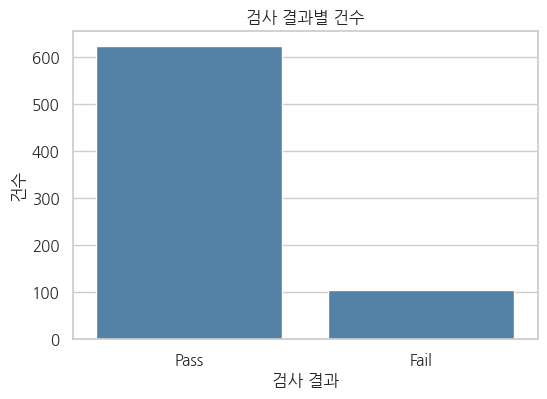

In [ ]:
# 여기 AI의 코드 붙여넣기
result_table = df['inspection_result'].value_counts().reindex(['Pass', 'Fail']).reset_index()
result_table.columns = ['검사 결과', '건수']
result_table['비율(%)'] = (
    result_table['건수'] / result_table['건수'].sum() * 100
).round(1)

print(result_table.to_string(index=False))

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x='inspection_result',
    order=['Pass', 'Fail'],
    color='steelblue'
)

plt.title('검사 결과별 건수')
plt.xlabel('검사 결과')
plt.ylabel('건수')
plt.show()




**Prompt**

Pass와 Fail의 건수와 비율을 제시하고, 항상 다수 클래스인 Pass로 예측했을 때의 기준 정확도를 포함해 3문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>
Pass는 624건(85.7%), Fail은 104건(14.3%)으로 Pass가 큰 비중을 차지합니다.
모든 데이터를 항상 다수 클래스인 Pass로만 예측해도 **기준 정확도는 85.7%**가 됩니다.
따라서 이후 분류 모델은 단순 정확도만 높이는 것이 아니라 이 기준 정확도보다 실제로 의미 있게 개선되는지도 함께 확인할 필요가 있습니다.

### 과제 1-5. 식별자 중복과 행별 결측치 분포를 확인하시오.


**Prompt**

현재 `df`에서 `wafer_id`의 고유값 수와 중복 수, 완전히 중복된 행의 수를 확인해 주세요. 수치형 공정 변수에서 각 행의 결측치 수를 계산해 요약 통계와 히스토그램도 출력하는 코드를 작성해 주세요.


wafer_id 고유값 수: 728
wafer_id 중복 수: 0
완전히 중복된 행의 수: 0

행별 수치형 공정 변수 결측치 수 요약 통계:
count    728.0000
mean       2.2212
std        1.5984
min        0.0000
25%        1.0000
50%        2.0000
75%        3.0000
max       12.0000


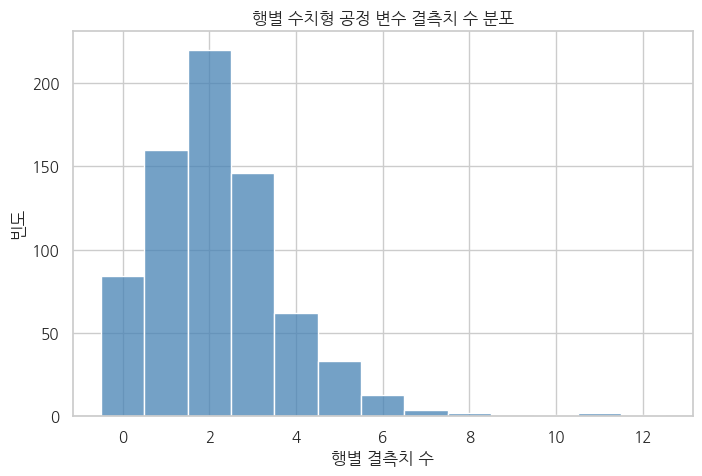

In [ ]:
# 여기 AI의 코드 붙여넣기
# wafer_id 고유값 수와 중복 수 확인
wafer_unique = df['wafer_id'].nunique()
wafer_duplicates = df['wafer_id'].duplicated().sum()

# 완전히 중복된 행의 수 확인
full_duplicates = df.duplicated().sum()

print('wafer_id 고유값 수:', wafer_unique)
print('wafer_id 중복 수:', wafer_duplicates)
print('완전히 중복된 행의 수:', full_duplicates)

# 수치형 공정 변수 선택
numeric_cols = df.select_dtypes(include='number').columns

# 각 행의 수치형 공정 변수 결측치 수 계산
row_missing_counts = df[numeric_cols].isnull().sum(axis=1)

# 요약 통계 출력
print('\n행별 수치형 공정 변수 결측치 수 요약 통계:')
print(row_missing_counts.describe().round(4).to_string())

# 히스토그램 출력
plt.figure(figsize=(8, 5))
sns.histplot(
    row_missing_counts,
    bins=range(int(row_missing_counts.max()) + 2),
    discrete=True,
    color='steelblue'
)

plt.title('행별 수치형 공정 변수 결측치 수 분포')
plt.xlabel('행별 결측치 수')
plt.ylabel('빈도')
plt.show()



**Prompt**

식별자와 중복 여부, 결측치가 있는 행의 수, 행별 평균과 최대 결측치 수를 4문장 이내로 해석해 주세요.


wafer_id는 728개가 모두 고유하여 식별자로 사용할 수 있으며, wafer_id 중복과 완전히 중복된 행은 모두 0건입니다.
수치형 공정 변수에 결측치가 있는 행은 약 644개로, 대부분의 행에 적어도 하나의 결측치가 있습니다.
행별 결측치 수는 평균 2.2212개입니다.
한 행에서 관측된 최대 결측치 수는 12개입니다.

---
## 2. 시각화 탐색

이제 공정 변수의 분포와 `Pass`·`Fail` 차이를 살펴본다.


### 과제 2-1. 모든 수치형 변수의 분포를 확인하시오. 6행 5열 subplot으로 분석하세요.

**Prompt**

현재 `df`의 모든 수치형 공정 변수를 6행 5열 subplot의 히스토그램으로 한눈에 비교하는 코드를 작성해 주세요. seaborn의 `histplot`을 사용하고 KDE 곡선도 표시하세요. 사용하지 않는 축은 숨겨 주세요.


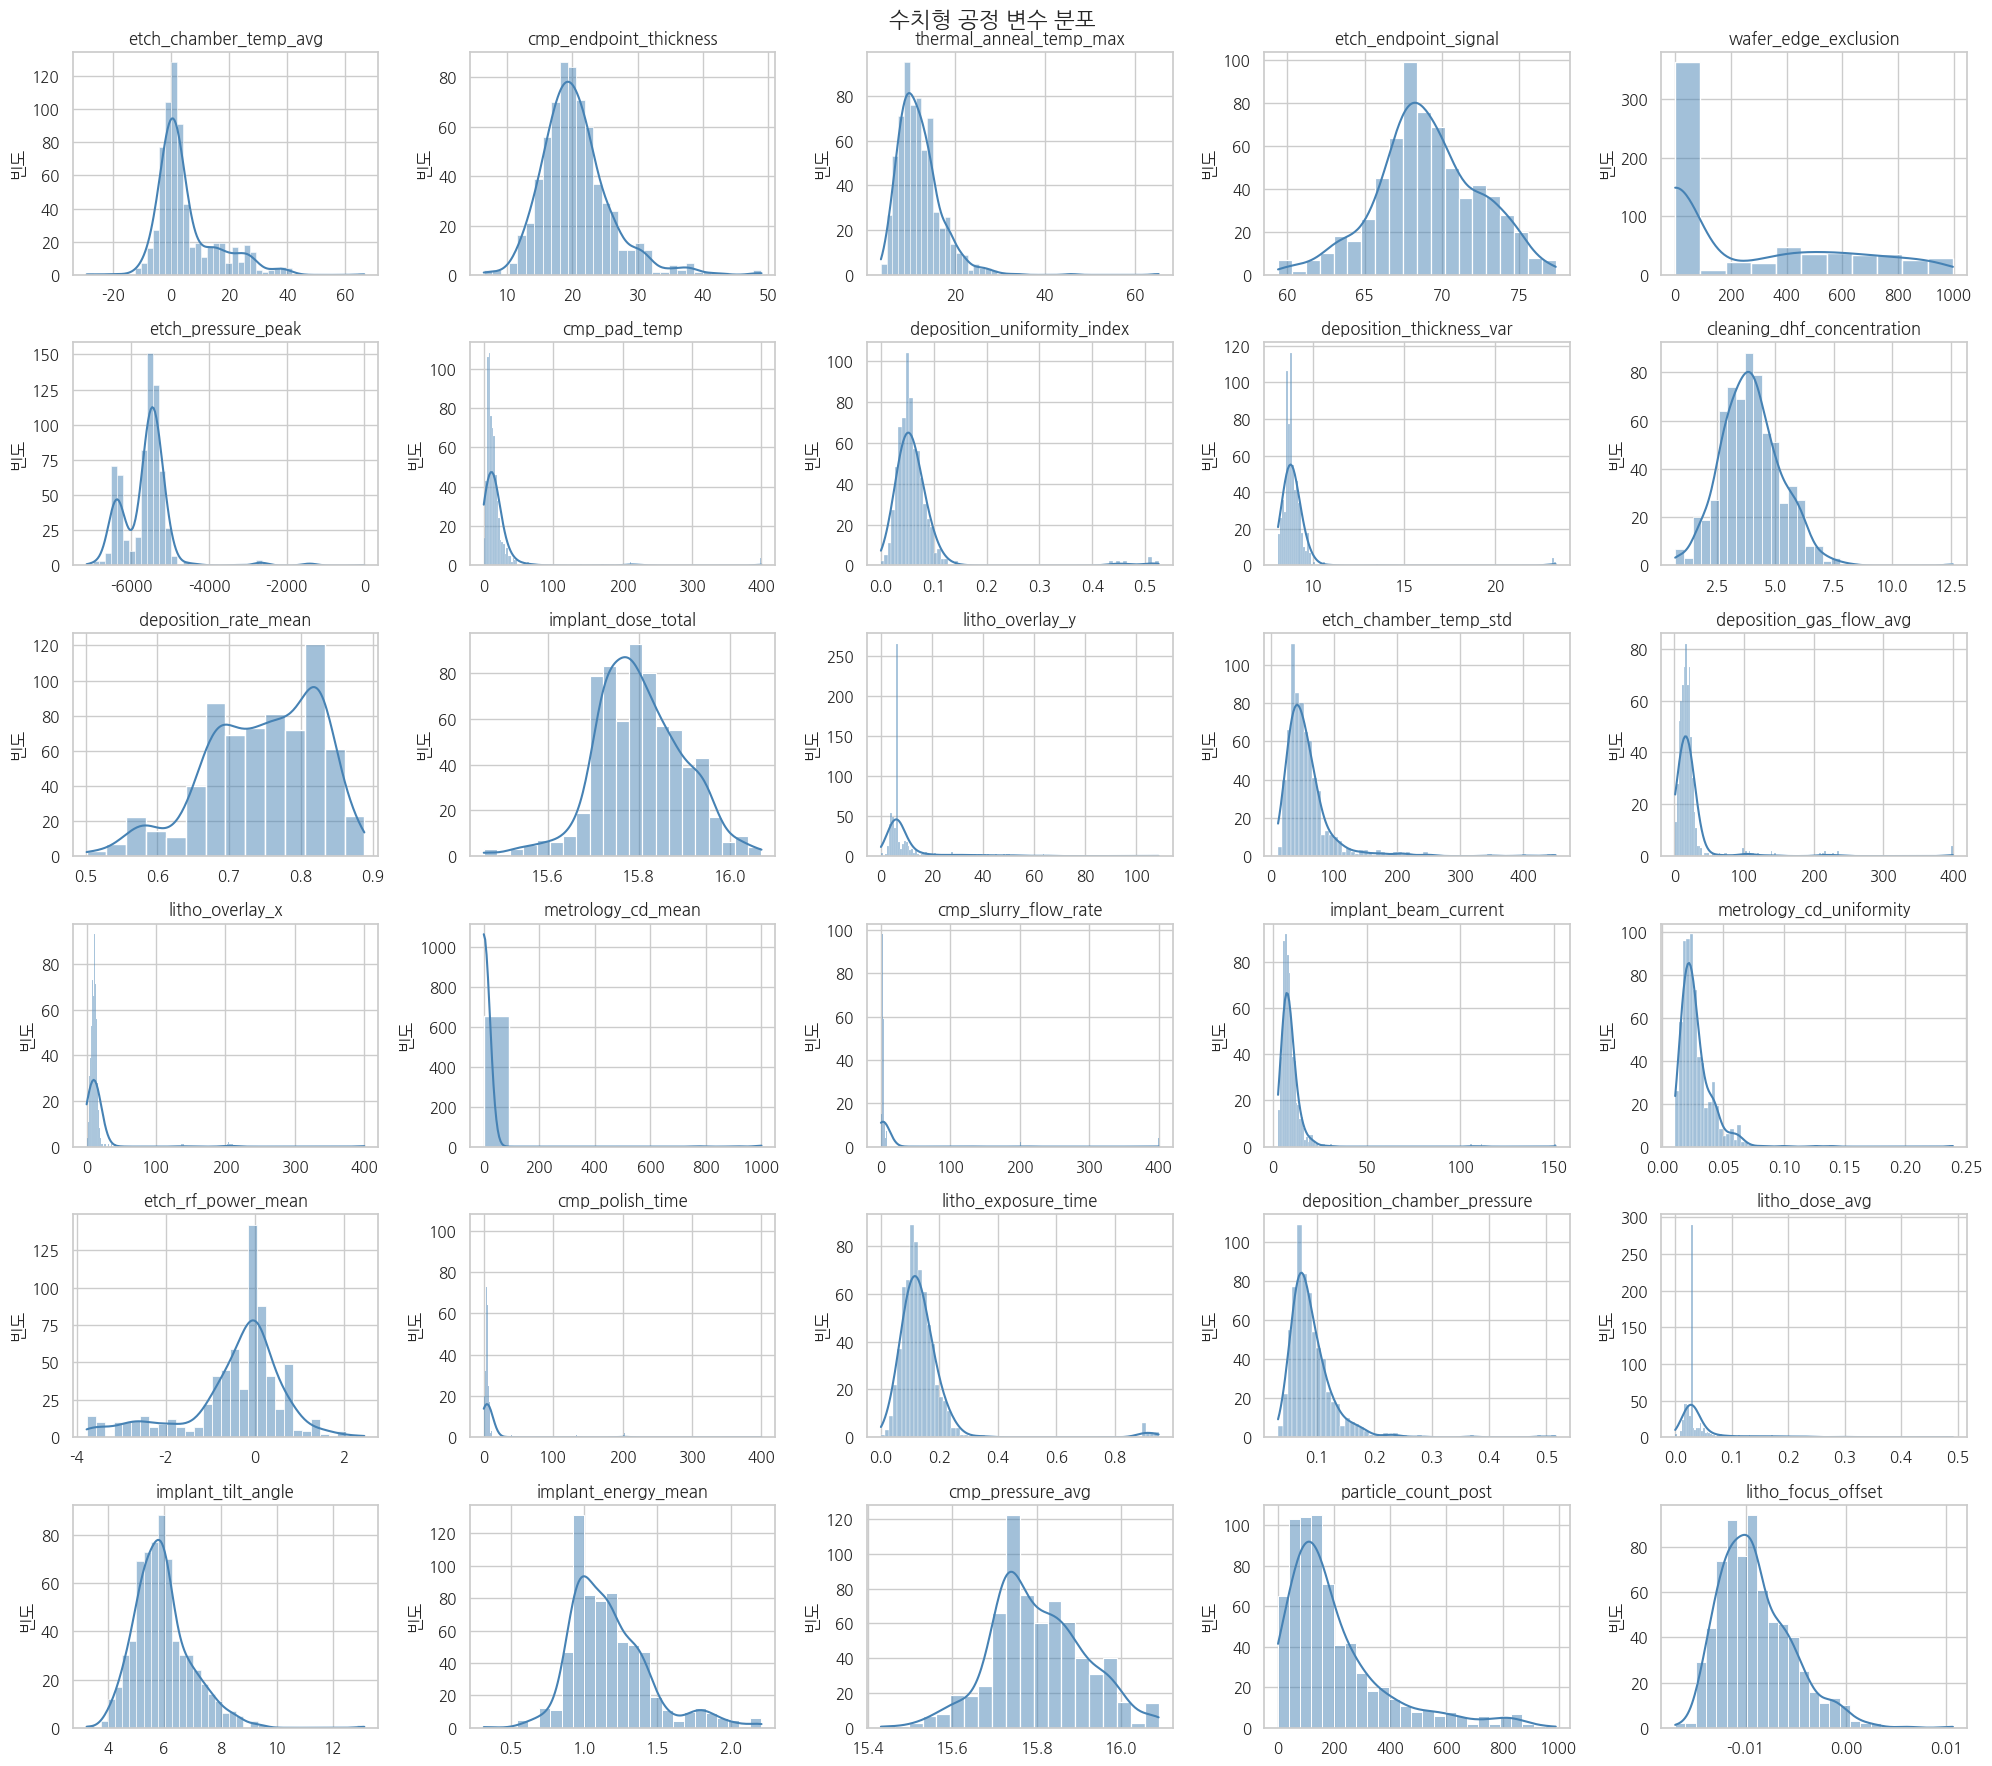

In [ ]:
# 여기 AI의 코드 붙여넣기
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('빈도')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 공정 변수 분포', fontsize=16)
plt.tight_layout()
plt.show()


**Prompt**

히스토그램을 바탕으로 전체적인 분포 형태와 큰 값이 두드러지는 변수, 비교적 좁은 범위에 모인 변수를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

전체적으로 여러 변수에서 한쪽으로 긴 꼬리가 나타나는 비대칭 분포가 확인되며, 일부 변수는 특정 구간에 값이 집중되어 있습니다.
metrology_cd_mean, cmp_slurry_flow_rate, litho_overlay_x, cmp_polish_time, litho_exposure_time 등은 대부분의 값보다 훨씬 큰 값이 일부 존재해 큰 값이 두드러집니다.
반면 implant_dose_total, deposition_rate_mean, cmp_pressure_avg, litho_focus_offset 등은 상대적으로 좁은 범위에 값이 모여 있습니다.
따라서 변수별 분포와 범위 차이가 크며, 일부 변수에는 극단값 또는 이상치 후보가 포함되어 있을 가능성이 있습니다.



### 과제 2-2. 모든 수치형 변수의 Pass·Fail별 KDE 분포를 비교하시오.


**Prompt**

현재 `df`의 모든 수치형 공정 변수에 대해 `inspection_result`로 구분한 KDE 곡선을 6행 5열 subplot으로 그리는 코드를 작성해 주세요. `Pass`와 `Fail`을 같은 축에서 비교하고, 두 그룹을 각각 정규화해 분포 모양을 비교할 수 있게 `common_norm=False`를 사용하세요.


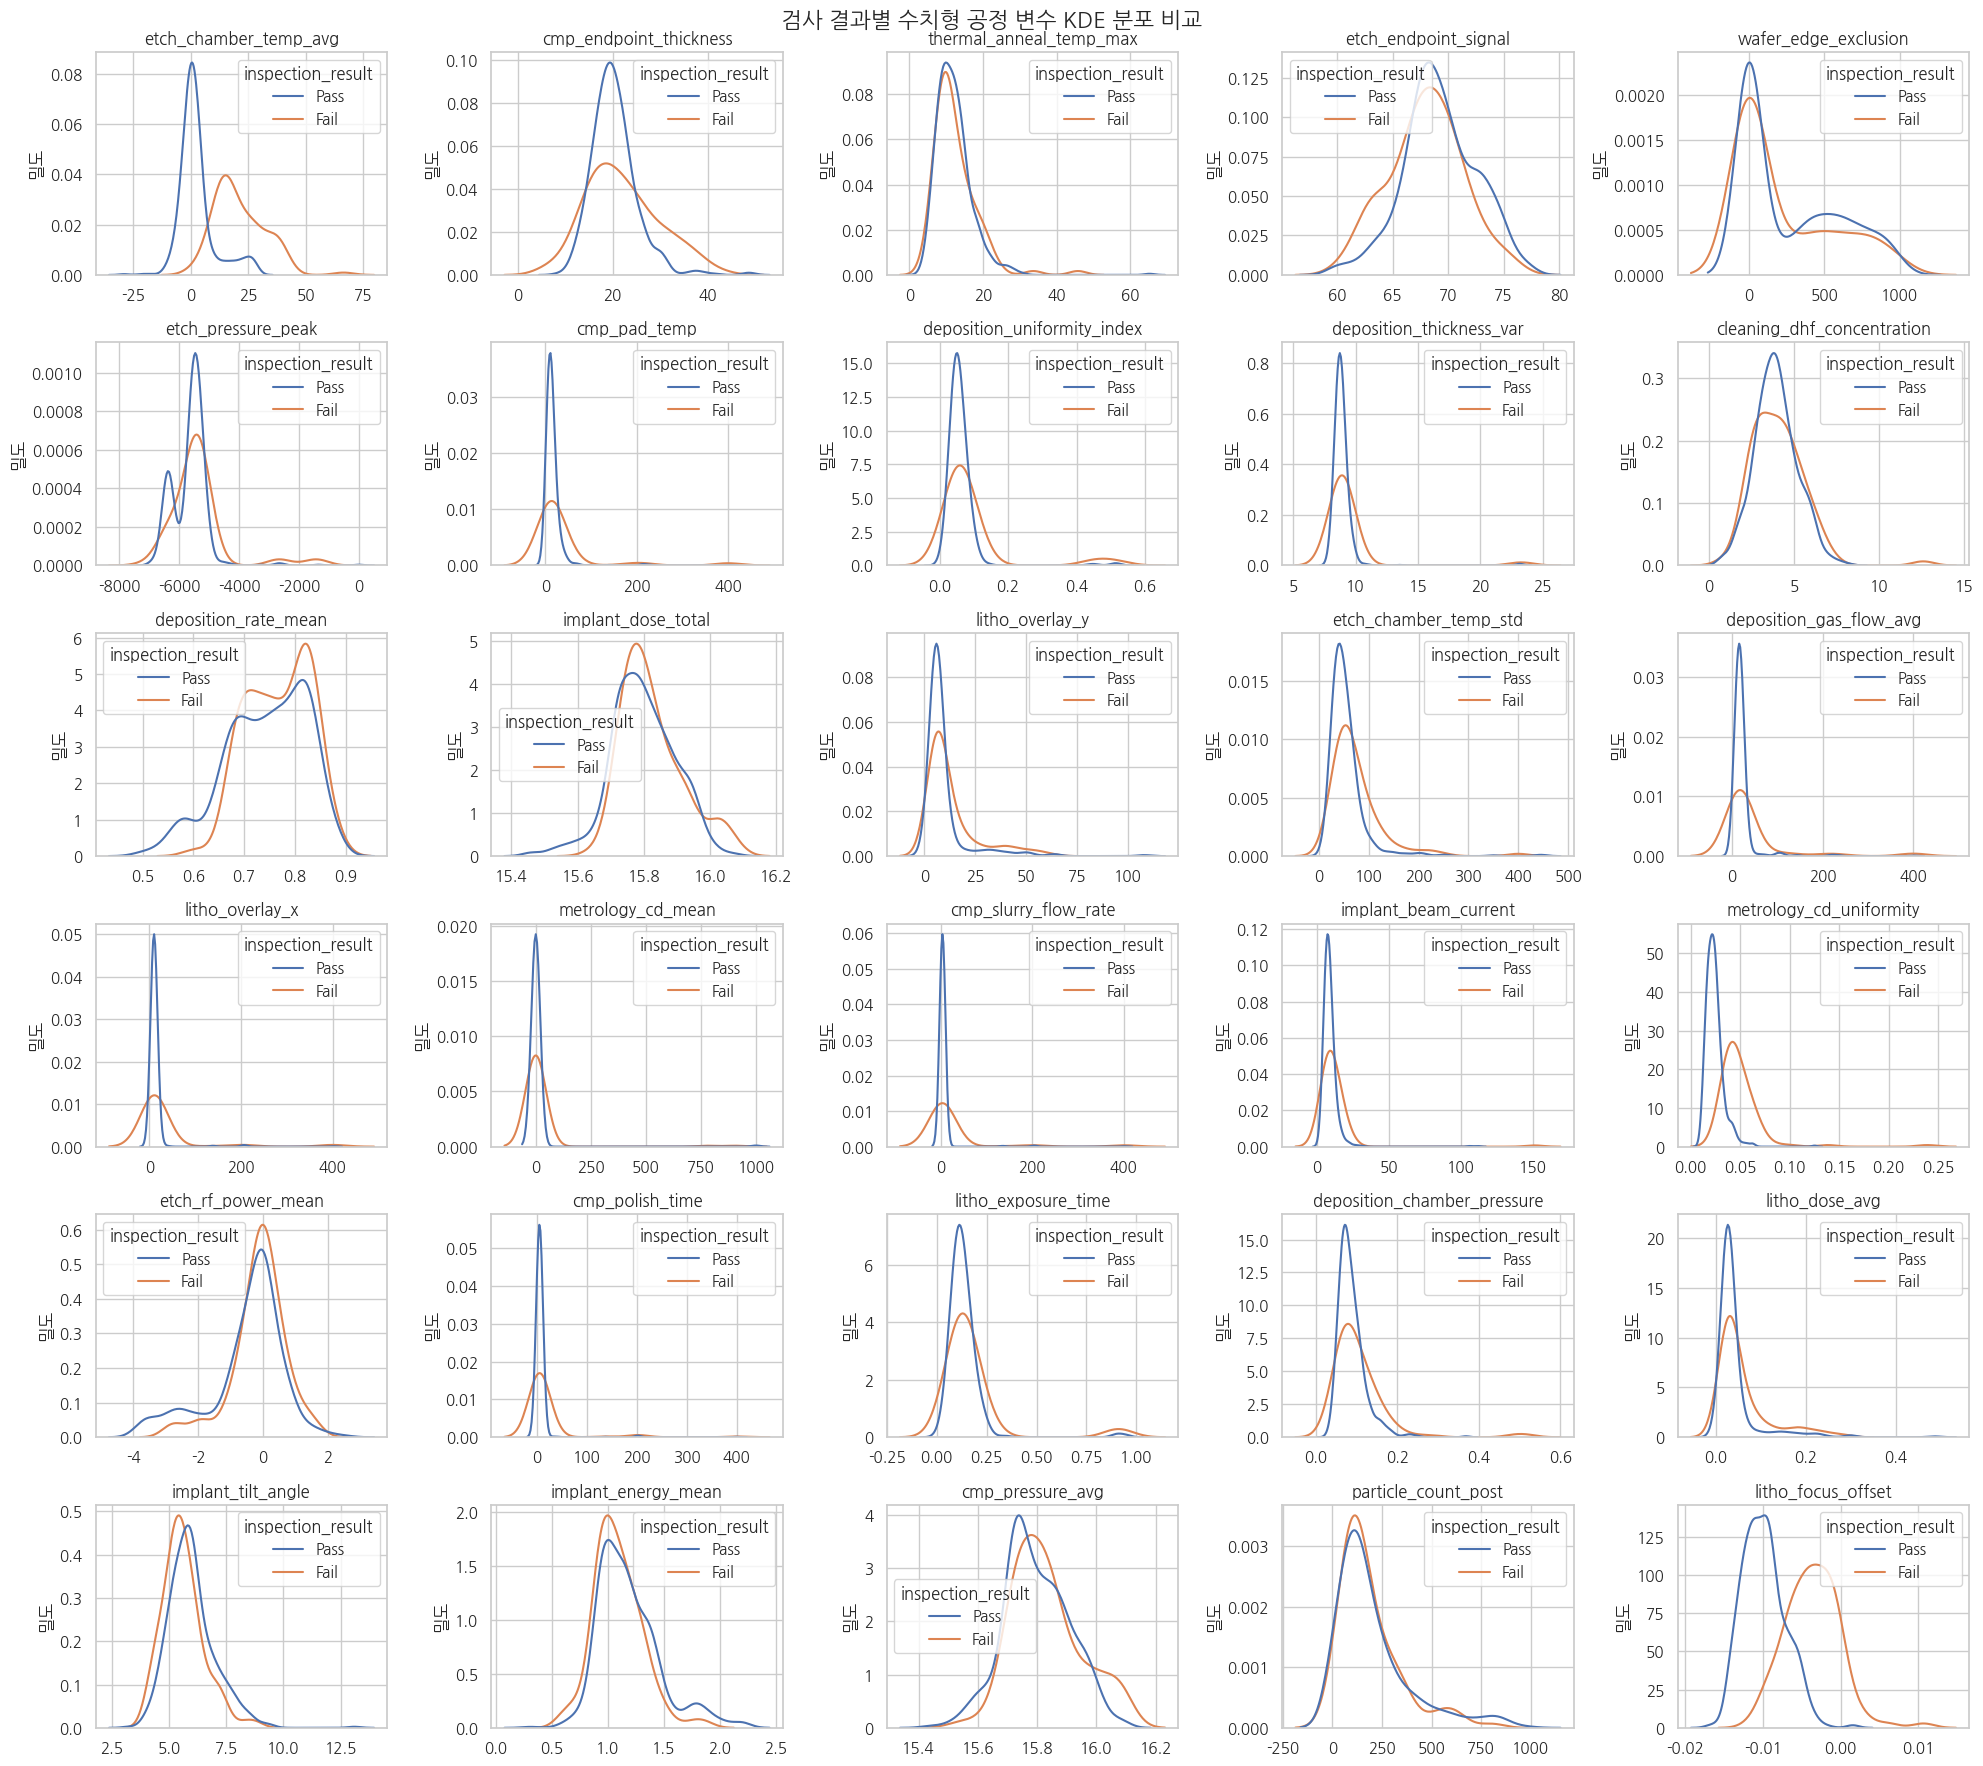

In [ ]:
# 여기 AI의 코드 붙여넣기
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='inspection_result',
        hue_order=['Pass', 'Fail'],
        common_norm=False,
        fill=False,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('밀도')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('검사 결과별 수치형 공정 변수 KDE 분포 비교', fontsize=16)
plt.tight_layout()
plt.show()


**추가 Prompt**

방금 직접 실행해 확인한 모든 수치형 변수의 Pass·Fail별 KDE 그래프를 바탕으로, 두 집단의 분포 차이를 박스플롯으로 추가 확인할 변수 6개를 선정해 주세요. 분포 중심의 이동, 두 분포의 겹침 정도, 이상치 일부가 만든 차이인지 여부를 고려하고, 각 변수의 선정 이유와 Fail에서 값이 커지는지 작아지는지를 표로 정리해 주세요. 새로운 계산이나 그래프 작성은 하지 마세요.

**해석:**
| 변수                            | 선정 이유                                                                               | Fail에서의 방향 |
| ----------------------------- | ----------------------------------------------------------------------------------- | ---------- |
| `etch_chamber_temp_avg`       | Pass는 0 부근에 강하게 집중되지만 Fail은 전체적으로 오른쪽으로 이동해 중심 차이가 뚜렷하고, 두 분포의 겹침도 상대적으로 작습니다.      | **커짐**     |
| `cmp_endpoint_thickness`      | Fail 분포가 Pass보다 더 넓고 오른쪽으로 치우쳐 있어 중심 이동과 분산 차이를 함께 확인할 가치가 있습니다.                    | **커짐**     |
| `metrology_cd_uniformity`     | Pass와 Fail의 봉우리 위치가 비교적 명확하게 분리되어 있고, Fail 쪽 중심이 오른쪽에 형성되어 있습니다.                    | **커짐**     |
| `litho_focus_offset`          | 두 집단의 KDE 중심이 가장 분명하게 떨어져 있는 변수 중 하나로, Fail 분포가 Pass보다 오른쪽으로 이동해 있습니다.              | **커짐**     |
| `deposition_uniformity_index` | Fail 분포가 더 넓고 오른쪽 꼬리 및 높은 값 구간에서 차이가 보여, 단순 이상치 때문인지 전체 분포 이동인지 박스플롯으로 확인하기 적합합니다.  | **커짐**     |
| `deposition_thickness_var`    | 대부분의 중심 구간에서도 Fail이 다소 오른쪽에 위치하지만 매우 큰 값도 일부 보여, 실제 중심 차이인지 극단값의 영향인지 구분할 필요가 있습니다. | **커짐**     |


### 과제 2-3. 주요 여섯 변수의 Pass·Fail별 박스플롯을 비교하시오.


**Prompt**

앞선 KDE 그래프 해석에서 선정한 `metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`, `etch_chamber_temp_std`, `litho_overlay_y`, `litho_dose_avg`를 signal_cols에 저장해 주세요. 각 변수마다 x축은 inspection_result, y축은 해당 변수인 박스플롯을 2행 3열로 그리는 코드를 작성해 주세요.


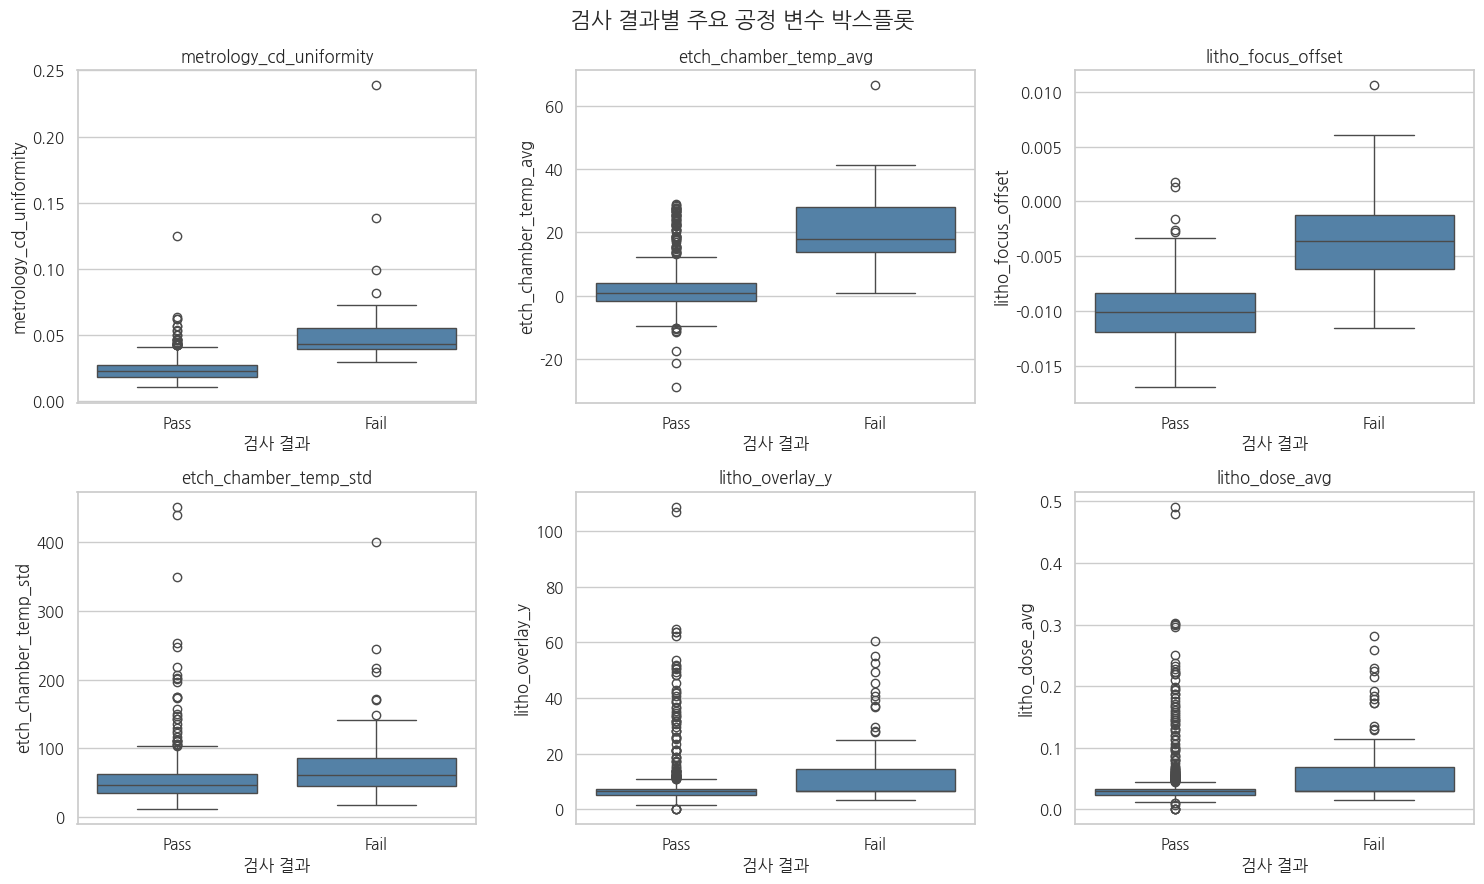

In [ ]:
# 여기 AI의 코드 붙여넣기
signal_cols = [
    'metrology_cd_uniformity',
    'etch_chamber_temp_avg',
    'litho_focus_offset',
    'etch_chamber_temp_std',
    'litho_overlay_y',
    'litho_dose_avg'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(signal_cols):
    sns.boxplot(
        data=df,
        x='inspection_result',
        y=col,
        order=['Pass', 'Fail'],
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('검사 결과')
    axes[i].set_ylabel(col)

plt.suptitle('검사 결과별 주요 공정 변수 박스플롯', fontsize=16)
plt.tight_layout()
plt.show()


**Prompt**

박스플롯을 바탕으로 Pass와 Fail의 차이가 뚜렷한 변수와 두 집단이 많이 겹치는 변수를 구분해 주세요. 각 변수의 중앙값 차이와 이상치의 영향을 포함해 4문장 이내로 해석하고, 관찰된 관계를 불량의 원인으로 단정하지 마세요.


해석:
metrology_cd_uniformity, etch_chamber_temp_avg, litho_focus_offset은 Pass와 Fail의 중앙값 위치가 뚜렷하게 달라 두 집단의 차이가 비교적 분명하게 보입니다.
etch_chamber_temp_std, litho_overlay_y, litho_dose_avg도 Fail의 중앙값이 Pass보다 높지만 상자와 수염이 상당 부분 겹쳐 집단 간 구분은 상대적으로 약합니다.
특히 etch_chamber_temp_std, litho_overlay_y, litho_dose_avg에는 양쪽 집단에 큰 이상치가 다수 존재하므로, 일부 극단값이 전체 차이를 더 크게 보이게 할 가능성도 있습니다.
따라서 이 박스플롯은 일부 공정 변수와 Fail 사이의 연관된 분포 차이를 보여 주지만, 이것만으로 해당 변수들이 불량의 원인이라고 단정할 수는 없습니다.

### 과제 2-4. 주요 변수의 Pass·Fail별 평균과 중앙값을 표로 비교하시오.


**Prompt**

현재 `df`와 `signal_cols`를 사용해 각 변수의 Pass·Fail별 유효 표본 수, 평균, 중앙값과 `Fail 평균 - Pass 평균`을 하나의 표로 정리하는 코드를 작성해 주세요. 결과는 소수점 넷째 자리까지 표시하세요.


In [ ]:
summary_list = []

for col in signal_cols:
    pass_data = df.loc[df['inspection_result'] == 'Pass', col].dropna()
    fail_data = df.loc[df['inspection_result'] == 'Fail', col].dropna()

    summary_list.append({
        '변수': col,
        'Pass 유효 표본 수': pass_data.count(),
        'Fail 유효 표본 수': fail_data.count(),
        'Pass 평균': pass_data.mean(),
        'Fail 평균': fail_data.mean(),
        'Pass 중앙값': pass_data.median(),
        'Fail 중앙값': fail_data.median(),
        'Fail 평균 - Pass 평균': fail_data.mean() - pass_data.mean()
    })

signal_summary = pd.DataFrame(summary_list)

signal_summary[
    ['Pass 평균', 'Fail 평균', 'Pass 중앙값', 'Fail 중앙값', 'Fail 평균 - Pass 평균']
] = signal_summary[
    ['Pass 평균', 'Fail 평균', 'Pass 중앙값', 'Fail 중앙값', 'Fail 평균 - Pass 평균']
].round(4)

print(signal_summary.to_string(index=False))


                     변수  Pass 유효 표본 수  Fail 유효 표본 수  Pass 평균  Fail 평균  Pass 중앙값  Fail 중앙값  Fail 평균 - Pass 평균
metrology_cd_uniformity           568           100   0.0243   0.0495    0.0229    0.0436             0.0252
  etch_chamber_temp_avg           591            97   2.5491  21.2798    0.9518   17.8968            18.7308
     litho_focus_offset           590           101  -0.0099  -0.0036   -0.0101   -0.0037             0.0063
  etch_chamber_temp_std           580            95  54.7930  74.7176   46.2492   61.3699            19.9246
        litho_overlay_y           564            98   9.3192  12.9162    6.3462    6.3529             3.5970
         litho_dose_avg           588            99   0.0426   0.0595    0.0295    0.0297             0.0169


**Prompt**

표본 수 차이와 세 핵심 변수의 평균 차이를 실제 수치로 제시하고, 단위가 다른 변수의 평균 차이를 직접 비교하면 안 되는 이유를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>
세 핵심 변수의 유효 표본 수는 metrology_cd_uniformity가 Pass 568개·Fail 100개, etch_chamber_temp_avg가 Pass 591개·Fail 97개, litho_focus_offset이 Pass 590개·Fail 101개로, 모든 변수에서 Pass 표본이 훨씬 많습니다.
Fail 평균 - Pass 평균은 metrology_cd_uniformity가 0.0252, etch_chamber_temp_avg가 18.7308, litho_focus_offset이 0.0063으로 모두 Fail 쪽 평균이 더 높았습니다.
다만 세 변수는 측정 단위와 값의 스케일이 서로 다르기 때문에, 평균 차이의 절댓값만 보고 어떤 변수가 더 큰 차이를 보인다고 직접 비교하면 안 됩니다.
변수 간 영향 크기를 비교하려면 이후 표준화된 차이처럼 단위의 영향을 제거한 지표를 사용하는 것이 적절합니다.

### 과제 2-5. 각 수치형 변수와 Fail 여부의 상관관계를 확인하시오.


**Prompt**

현재 `df`에 `Fail`이면 1, `Pass`이면 0인 `불량값` 컬럼을 만들고, 모든 수치형 공정 변수와 `불량값`의 상관계수를 절댓값이 큰 순서로 표와 가로 막대그래프로 출력하는 코드를 작성해 주세요.


                         변수    상관계수
      etch_chamber_temp_avg  0.6143
         litho_focus_offset  0.6129
    metrology_cd_uniformity  0.5769
    deposition_gas_flow_avg  0.1761
            litho_overlay_x  0.1669
               cmp_pad_temp  0.1654
deposition_uniformity_index  0.1645
       cmp_slurry_flow_rate  0.1629
      etch_chamber_temp_std  0.1623
deposition_chamber_pressure  0.1526
         etch_pressure_peak  0.1426
       etch_endpoint_signal -0.1307
         implant_tilt_angle -0.1296
        implant_energy_mean -0.1234
        litho_exposure_time  0.1231
     cmp_endpoint_thickness  0.1186
         etch_rf_power_mean  0.1172
   deposition_thickness_var  0.1163
             litho_dose_avg  0.1143
            cmp_polish_time  0.1125
       deposition_rate_mean  0.1115
            litho_overlay_y  0.1107
           cmp_pressure_avg  0.1068
       implant_beam_current  0.1066
         implant_dose_total  0.1022
          metrology_cd_mean  0.0504
       wafer_edge_exclusion 

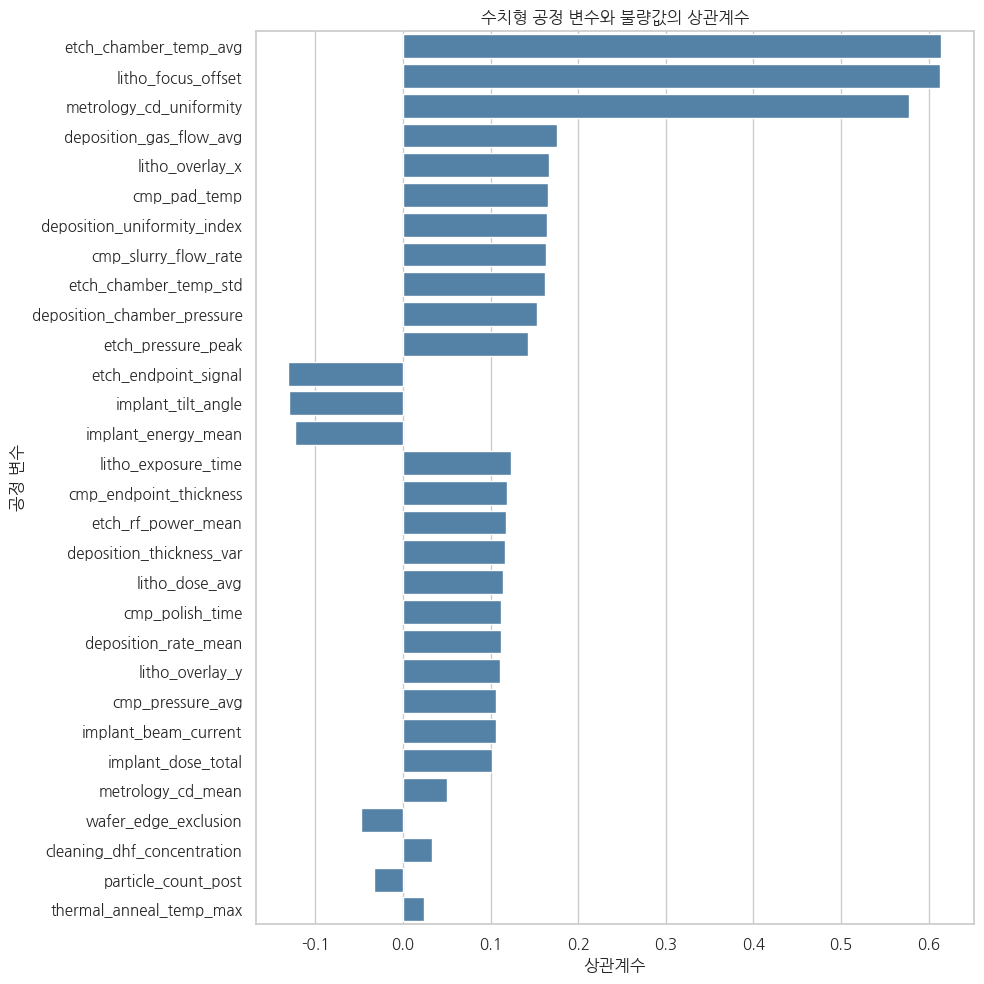

In [ ]:
# 여기 AI의 코드 붙여넣기
df['불량값'] = df['inspection_result'].map({
    'Pass': 0,
    'Fail': 1
})

numeric_cols = df.select_dtypes(include='number').columns.drop('불량값')

correlations = (
    df[numeric_cols]
    .corrwith(df['불량값'])
    .sort_values(key=abs, ascending=False)
)

corr_table = pd.DataFrame({
    '변수': correlations.index,
    '상관계수': correlations.values
})

corr_table['상관계수'] = corr_table['상관계수'].round(4)

print(corr_table.to_string(index=False))

plt.figure(figsize=(10, 10))

sns.barplot(
    data=corr_table,
    x='상관계수',
    y='변수',
    color='steelblue'
)

plt.title('수치형 공정 변수와 불량값의 상관계수')
plt.xlabel('상관계수')
plt.ylabel('공정 변수')
plt.tight_layout()
plt.show()



**Prompt**

Fail 여부와 상관계수 절댓값이 가장 큰 세 변수와 각각의 값을 제시하고, 그다음 변수들과의 차이를 4문장 이내로 해석해 주세요. 상관관계를 인과관계로 표현하지 마세요.


**해석:** <여기 AI의 해석을 붙여넣기>

Fail 여부와 상관계수 절댓값이 가장 큰 세 변수는 etch_chamber_temp_avg 0.6143, litho_focus_offset 0.6129, metrology_cd_uniformity 0.5769입니다.
세 변수 모두 양의 상관을 보여 값이 커질수록 Fail=1과 함께 나타나는 경향이 상대적으로 강했습니다.
그다음으로 큰 deposition_gas_flow_avg는 0.1761로, 상위 3개 변수와 비교하면 상관계수 크기가 크게 낮아집니다.
따라서 상위 3개 변수가 다른 변수들보다 Fail 여부와 더 뚜렷한 선형 연관성을 보이지만, 이는 상관관계이며 불량의 원인이라는 뜻은 아닙니다.


### 과제 2-6. 주요 변수들의 상관관계를 히트맵으로 확인하시오.


**Prompt**

현재 `df`에서 `불량값`과 `signal_cols`의 상관관계 행렬을 계산하고, 값을 표시한 seaborn 히트맵으로 시각화하는 코드를 작성해 주세요. 색상 범위는 -1부터 1까지로 고정하세요.


                            불량값  metrology_cd_uniformity  etch_chamber_temp_avg  litho_focus_offset  etch_chamber_temp_std  litho_overlay_y  litho_dose_avg
불량값                      1.0000                   0.5769                 0.6143              0.6129                 0.1623           0.1107          0.1143
metrology_cd_uniformity  0.5769                   1.0000                 0.4153              0.4541                 0.1366           0.1407          0.1808
etch_chamber_temp_avg    0.6143                   0.4153                 1.0000              0.5671                 0.2662           0.2876          0.2936
litho_focus_offset       0.6129                   0.4541                 0.5671              1.0000                 0.5854           0.2164          0.2218
etch_chamber_temp_std    0.1623                   0.1366                 0.2662              0.5854                 1.0000           0.1013          0.1128
litho_overlay_y          0.1107                   0.1407        

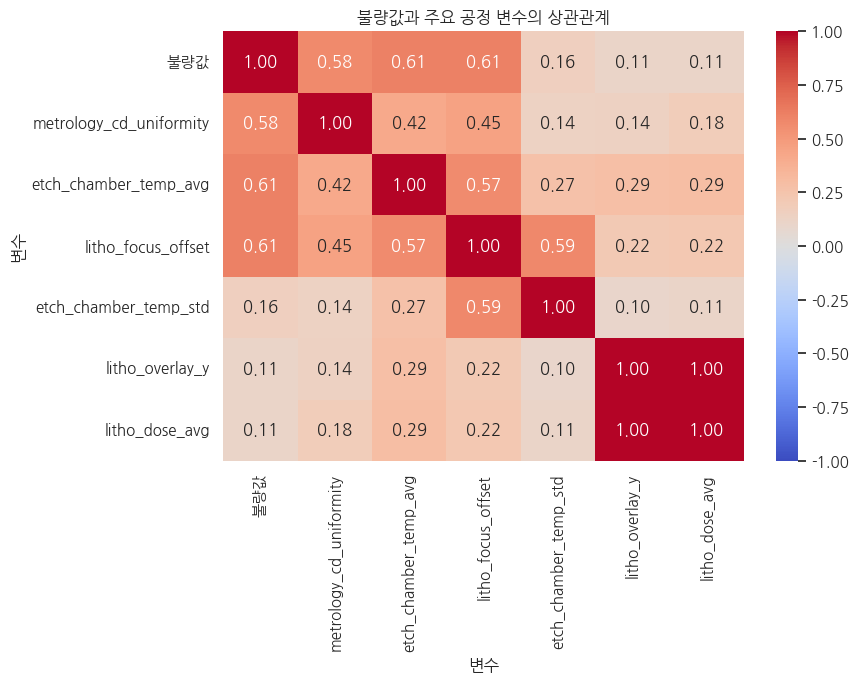

In [ ]:
# 여기 AI의 코드 붙여넣기
corr_cols = ['불량값'] + signal_cols

corr_matrix = df[corr_cols].corr()

print(corr_matrix.round(4).to_string())

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('불량값과 주요 공정 변수의 상관관계')
plt.xlabel('변수')
plt.ylabel('변수')
plt.tight_layout()
plt.show()


**Prompt**

불량값과 주요 변수의 관계뿐 아니라 핵심 변수들끼리의 상관관계도 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>
불량값과의 상관계수는 etch_chamber_temp_avg 0.6143, litho_focus_offset 0.6129, metrology_cd_uniformity 0.5769로 비교적 높았고, etch_chamber_temp_std는 0.1623, litho_overlay_y는 0.1107, litho_dose_avg는 0.1143으로 낮았습니다.
핵심 변수들끼리는 litho_overlay_y와 litho_dose_avg의 상관계수가 0.9996으로 거의 완전히 같은 방향으로 움직였고, litho_focus_offset과 etch_chamber_temp_std도 0.5854로 비교적 높은 양의 상관을 보였습니다.
또한 etch_chamber_temp_avg와 litho_focus_offset은 0.5671, metrology_cd_uniformity와 litho_focus_offset은 0.4541, metrology_cd_uniformity와 etch_chamber_temp_avg는 0.4153으로 중간 정도의 양의 상관이 나타났습니다.
따라서 일부 핵심 변수들은 불량값과의 연관성뿐 아니라 변수들끼리도 함께 움직이는 경향이 있어, 이후 해석에서는 서로 중복된 정보를 담고 있을 가능성도 함께 고려해야 합니다.

### 과제 2-7. 세 핵심 변수의 관계를 산점도로 확인하시오.


**Prompt**

현재 `df`에서 `metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`의 두 변수 조합 세 개를 1행 3열 산점도로 그려 주세요. `inspection_result`에 따라 색을 다르게 하고, Pass를 먼저 그린 뒤 Fail이 잘 보이게 해 주세요.


In [ ]:
# 여기 AI의 코드 붙여넣기



**Prompt**

산점도에서 Fail이 주로 모이는 방향과 Pass·Fail이 겹치는 영역을 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

---
## 3. 핵심 변수 심화 분석


### 과제 3-1. `metrology_cd_uniformity`를 0.025, 0.035, 0.040 기준값으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `metrology_cd_uniformity`를 `<0.025`, `0.025~<0.035`, `0.035~<0.040`, `>=0.040`으로 구간화해 `CD균일도구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고, 해당 변수의 결측치 수와 결측치 중 Fail 수를 함께 확인하는 코드를 작성해 주세요.


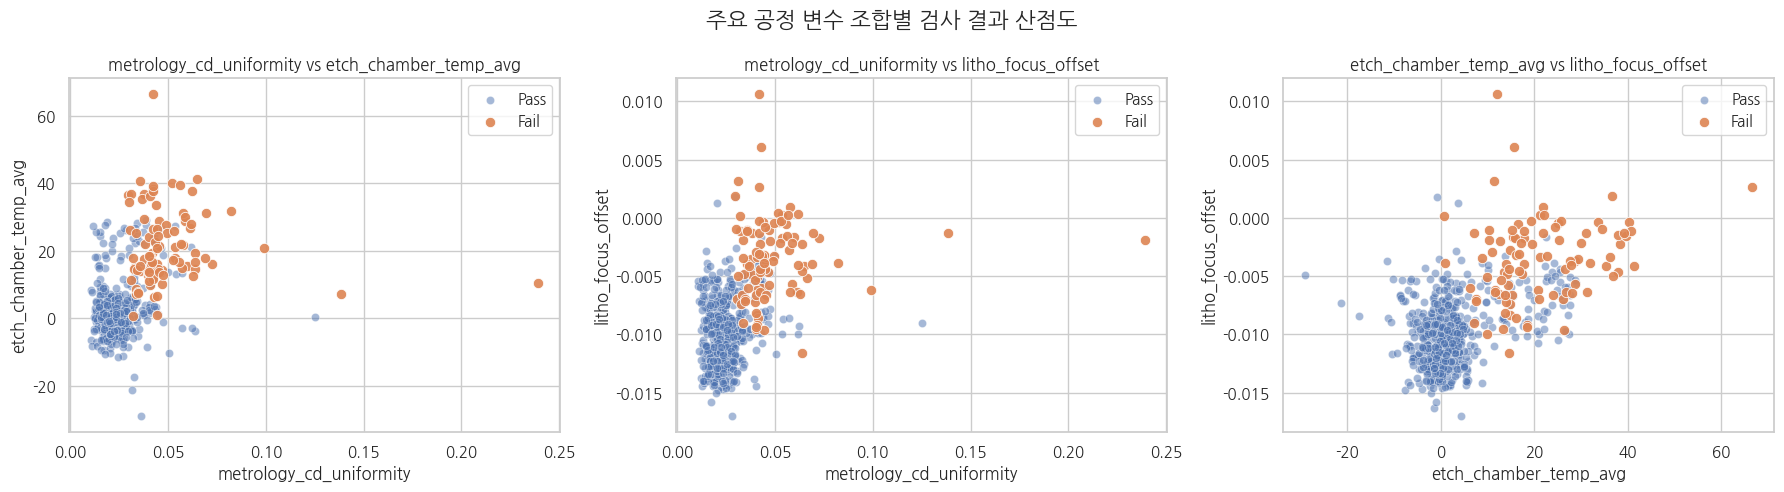

In [ ]:
# 여기 AI의 코드 붙여넣기
plot_cols = [
    'metrology_cd_uniformity',
    'etch_chamber_temp_avg',
    'litho_focus_offset'
]

pairs = [
    ('metrology_cd_uniformity', 'etch_chamber_temp_avg'),
    ('metrology_cd_uniformity', 'litho_focus_offset'),
    ('etch_chamber_temp_avg', 'litho_focus_offset')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    pass_data = df[df['inspection_result'] == 'Pass']
    fail_data = df[df['inspection_result'] == 'Fail']

    sns.scatterplot(
        data=pass_data,
        x=x_col,
        y=y_col,
        ax=ax,
        label='Pass',
        alpha=0.5,
        s=35
    )

    sns.scatterplot(
        data=fail_data,
        x=x_col,
        y=y_col,
        ax=ax,
        label='Fail',
        alpha=0.9,
        s=55
    )

    ax.set_title(f'{x_col} vs {y_col}')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.suptitle('주요 공정 변수 조합별 검사 결과 산점도', fontsize=16)
plt.tight_layout()
plt.show()


**Prompt**

각 구간의 전체 수와 불량률을 실제 수치로 비교하고 `>=0.040`을 룰 후보로 사용할 수 있는 이유를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

세 산점도 모두에서 Fail은 대체로 metrology_cd_uniformity, etch_chamber_temp_avg, litho_focus_offset 값이 Pass보다 큰 방향에 더 많이 모여 있습니다.
특히 etch_chamber_temp_avg가 높고 litho_focus_offset이 0에 가까워지는 영역, 그리고 metrology_cd_uniformity가 대략 0.04 이상인 영역에서 Fail 점들이 상대적으로 많이 나타납니다.
반면 metrology_cd_uniformity 약 0.03~0.05, etch_chamber_temp_avg 약 0~15, litho_focus_offset 약 -0.010~-0.005 부근에서는 Pass와 Fail이 상당히 겹칩니다.
따라서 세 변수의 조합으로 두 집단의 분포 차이는 관찰되지만, 겹치는 영역도 있어 단순한 한두 개 기준만으로 완전히 구분되지는 않습니다.

### 과제 3-2. `litho_focus_offset`을 -0.008, -0.006, -0.004 기준으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `litho_focus_offset`을 `< -0.008`, `-0.008~ < -0.006`, `-0.006~ < -0.004`, `>=-0.004`로 구간화해 `초점오프셋구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고 결측치 정보도 확인하는 코드를 작성해 주세요.


초점오프셋 구간별 요약:
         초점오프셋구간  전체수  불량수  불량률(%)
        < -0.008  466   11     2.4
-0.008~ < -0.006   93   18    19.4
-0.006~ < -0.004   65   17    26.2
       >= -0.004   67   55    82.1

litho_focus_offset 결측치 수: 37
litho_focus_offset 결측률(%): 5.1


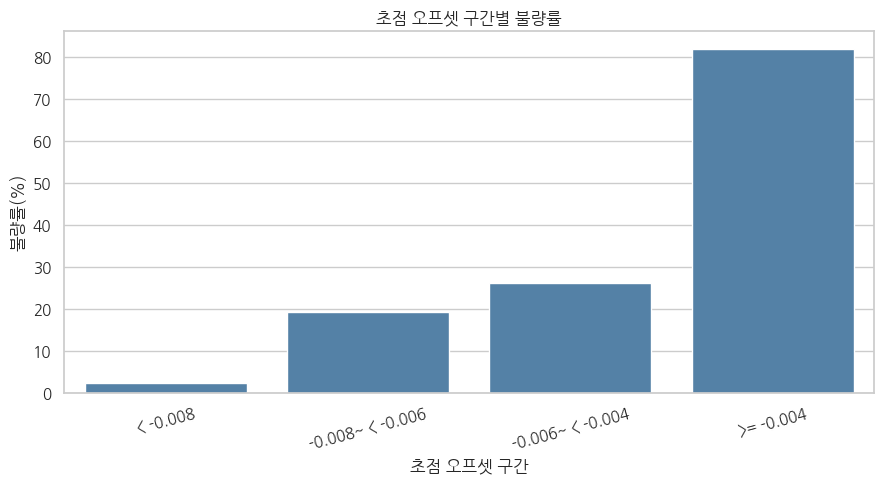

In [ ]:
# 여기 AI의 코드 붙여넣기
bins = [-np.inf, -0.008, -0.006, -0.004, np.inf]

labels = [
    '< -0.008',
    '-0.008~ < -0.006',
    '-0.006~ < -0.004',
    '>= -0.004'
]

df['초점오프셋구간'] = pd.cut(
    df['litho_focus_offset'],
    bins=bins,
    labels=labels,
    right=False
)

focus_summary = (
    df.groupby('초점오프셋구간', observed=False)
      .agg(
          전체수=('불량값', 'count'),
          불량수=('불량값', 'sum')
      )
      .reset_index()
)

focus_summary['불량률(%)'] = (
    focus_summary['불량수'] / focus_summary['전체수'] * 100
).round(1)

print('초점오프셋 구간별 요약:')
print(focus_summary.to_string(index=False))

focus_missing = df['litho_focus_offset'].isnull().sum()
focus_missing_rate = round(df['litho_focus_offset'].isnull().mean() * 100, 1)

print('\nlitho_focus_offset 결측치 수:', focus_missing)
print('litho_focus_offset 결측률(%):', focus_missing_rate)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=focus_summary,
    x='초점오프셋구간',
    y='불량률(%)',
    order=labels,
    color='steelblue'
)

plt.title('초점 오프셋 구간별 불량률')
plt.xlabel('초점 오프셋 구간')
plt.ylabel('불량률(%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



**Prompt**

각 구간의 불량률 변화와 `>=-0.004` 조건의 표본 수·불량 수를 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

litho_focus_offset 구간별 불량률은 < -0.008에서 2.4%, -0.008~< -0.006에서 19.4%, -0.006~< -0.004에서 26.2%, >= -0.004에서 **82.1%**로 단계적으로 높아졌습니다.
특히 >= -0.004 구간은 전체 67개 중 55개가 불량으로, 네 구간 중 불량률이 가장 높았습니다.
반면 < -0.008 구간은 466개 중 11개만 불량으로 불량률이 매우 낮았습니다.
따라서 초점 오프셋 값이 -0.004 이상인 구간에서 불량이 집중되는 경향이 뚜렷하게 관찰됩니다.

### 과제 3-3. `etch_chamber_temp_avg`를 0, 5, 10, 20을 기준값으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `etch_chamber_temp_avg`를 `<0`, `0~<5`, `5~<10`, `10~<20`, `>=20`으로 구간화해 `식각온도구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고 결측치 정보도 확인하는 코드를 작성해 주세요.


식각 온도 구간별 요약:
식각온도구간  전체수  불량수  불량률(%)
   < 0  236    0     0.0
  0~<5  242    2     0.8
 5~<10   52    9    17.3
10~<20   75   42    56.0
 >= 20   83   44    53.0

etch_chamber_temp_avg 결측치 수: 40
etch_chamber_temp_avg 결측률(%): 5.5


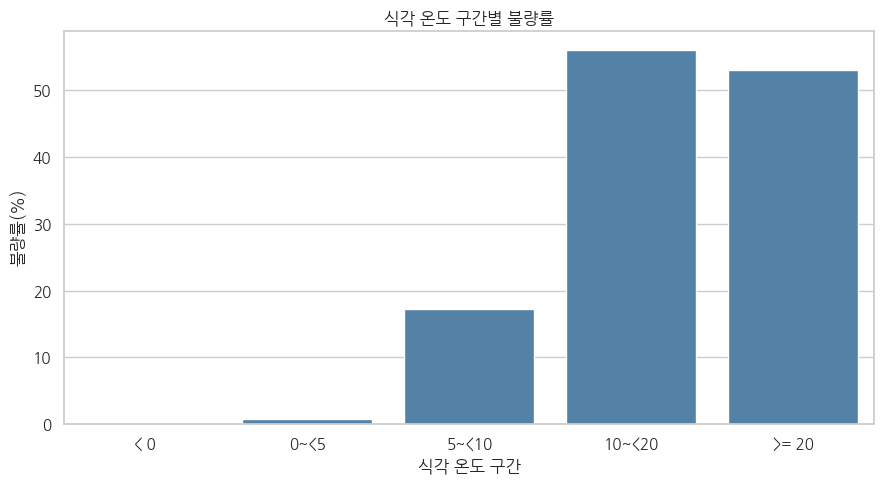

In [ ]:
# etch_chamber_temp_avg 구간화
bins = [-np.inf, 0, 5, 10, 20, np.inf]

labels = [
    '< 0',
    '0~<5',
    '5~<10',
    '10~<20',
    '>= 20'
]

df['식각온도구간'] = pd.cut(
    df['etch_chamber_temp_avg'],
    bins=bins,
    labels=labels,
    right=False
)

# 구간별 전체 수, 불량 수, 불량률 계산
temp_summary = (
    df.groupby('식각온도구간', observed=False)
      .agg(
          전체수=('불량값', 'count'),
          불량수=('불량값', 'sum')
      )
      .reset_index()
)

temp_summary['불량률(%)'] = (
    temp_summary['불량수'] / temp_summary['전체수'] * 100
).round(1)

print('식각 온도 구간별 요약:')
print(temp_summary.to_string(index=False))

# 결측치 정보 확인
temp_missing = df['etch_chamber_temp_avg'].isnull().sum()
temp_missing_rate = round(
    df['etch_chamber_temp_avg'].isnull().mean() * 100,
    1
)

print('\netch_chamber_temp_avg 결측치 수:', temp_missing)
print('etch_chamber_temp_avg 결측률(%):', temp_missing_rate)

# 불량률 막대그래프
plt.figure(figsize=(9, 5))

sns.barplot(
    data=temp_summary,
    x='식각온도구간',
    y='불량률(%)',
    order=labels,
    color='steelblue'
)

plt.title('식각 온도 구간별 불량률')
plt.xlabel('식각 온도 구간')
plt.ylabel('불량률(%)')
plt.tight_layout()
plt.show()

**Prompt**

10 미만과 10 이상 구간의 불량률을 실제 수치로 비교하고 `>=10` 조건의 장점과 한계를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

etch_chamber_temp_avg가 10 미만인 구간은 전체 530개 중 11개가 불량으로 불량률 약 2.1%, 10 이상은 전체 **158개 중 86개가 불량으로 불량률 약 54.4%**입니다.
따라서 >=10 조건은 불량이 많이 발생하는 구간을 비교적 명확하게 구분할 수 있다는 장점이 있습니다.
다만 >=10인 158개 중에도 72개는 Pass이므로 이 조건만으로 불량을 완전히 판별할 수는 없습니다.
또한 10 미만에서도 11개의 Fail이 존재하므로 >=10은 유용한 경고 기준이 될 수 있지만 단독 판정 기준으로 사용하기에는 한계가 있습니다.


### 과제 3-4. 세 핵심 조건의 위험 신호 수와 불량률을 확인하시오.


**Prompt**

현재 `df`에서 `metrology_cd_uniformity >= 0.040`, `litho_focus_offset >= -0.004`, `etch_chamber_temp_avg >= 10`의 참·거짓을 각각 저장하고, 한 웨이퍼가 만족하는 조건 수를 `위험신호수`로 만드세요. 위험신호수 0~3별 전체 수·불량 수·불량률을 표와 막대그래프로 확인하는 코드를 작성해 주세요. 결측치 비교는 False로 처리하세요.


위험신호수별 요약:
 위험신호수  전체수  불량수  불량률(%)
     0  534    6     1.1
     1   94   18    19.1
     2   60   43    71.7
     3   40   37    92.5


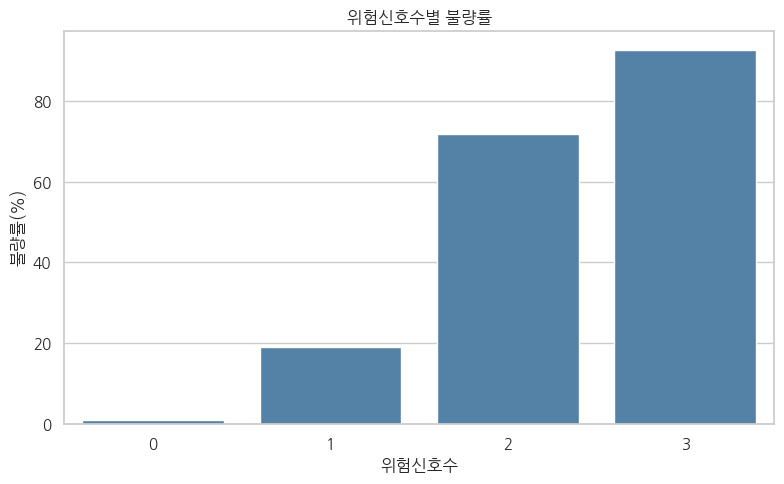

In [ ]:
# 여기 AI의 코드 붙여넣기
# 각 위험 조건을 참/거짓으로 저장
# NaN과의 비교는 자동으로 False가 됩니다.
df['CD균일도위험'] = df['metrology_cd_uniformity'] >= 0.040
df['초점오프셋위험'] = df['litho_focus_offset'] >= -0.004
df['식각온도위험'] = df['etch_chamber_temp_avg'] >= 10

# 한 웨이퍼가 만족하는 위험 조건 수 계산
df['위험신호수'] = (
    df['CD균일도위험'].astype(int)
    + df['초점오프셋위험'].astype(int)
    + df['식각온도위험'].astype(int)
)

# 위험신호수 0~3별 전체 수, 불량 수, 불량률 계산
risk_summary = (
    df.groupby('위험신호수')
      .agg(
          전체수=('불량값', 'count'),
          불량수=('불량값', 'sum')
      )
      .reindex([0, 1, 2, 3], fill_value=0)
      .reset_index()
)

risk_summary['불량률(%)'] = (
    risk_summary['불량수'] / risk_summary['전체수'] * 100
).round(1)

print('위험신호수별 요약:')
print(risk_summary.to_string(index=False))

# 불량률 막대그래프
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_summary,
    x='위험신호수',
    y='불량률(%)',
    order=[0, 1, 2, 3],
    color='steelblue'
)

plt.title('위험신호수별 불량률')
plt.xlabel('위험신호수')
plt.ylabel('불량률(%)')
plt.tight_layout()
plt.show()



**Prompt**

위험신호수 0~3별 표본 수와 불량률의 변화를 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

위험신호수가 0개인 경우 534개 중 불량률 1.1%, 1개인 경우 94개 중 19.1%로 증가했습니다.
위험신호수가 2개이면 60개 중 불량률 71.7%, 3개이면 40개 중 92.5%로 크게 높아졌습니다.
즉 위험신호수가 많아질수록 표본 수는 534개 → 94개 → 60개 → 40개로 줄어드는 반면, 불량률은 1.1% → 19.1% → 71.7% → 92.5%로 뚜렷하게 상승했습니다.
따라서 세 조건을 함께 만족할수록 Fail과 강하게 연관된 패턴이 나타나지만, 이는 관찰된 연관성이지 불량의 원인을 의미하지는 않습니다.

---
## 4. 핵심 변수에서 불량 룰 만들기

3장에서 구간별 불량률을 확인한 세 변수만 룰 후보로 사용한다. 임계값을 조사하지 않은 다른 변수에는 임의의 판정 기준을 만들지 않는다.


### 과제 4-1. 3장에서 확인한 세 임계값을 불량 룰 후보로 만들고 비교하시오.

- `rule1`: `metrology_cd_uniformity >= 0.040`
- `rule2`: `litho_focus_offset >= -0.004`
- `rule3`: `etch_chamber_temp_avg >= 10`


**Prompt**

현재 `df`에서 3장의 구간별 불량률 분석으로 확인한 다음 세 조건을 각각 하나의 불량 룰 후보로 만드세요.

- `rule1`: `metrology_cd_uniformity >= 0.040`
- `rule2`: `litho_focus_offset >= -0.004`
- `rule3`: `etch_chamber_temp_avg >= 10`

각 조건을 만족하는 웨이퍼 수, 실제 Fail 수, 실제 Pass 수, 불량률, 전체 불량률보다 몇 %p 높은지를 하나의 표로 비교하는 코드를 작성해 주세요. 이후 과제에서도 사용할 수 있도록 각 조건의 참·거짓 결과를 `rule1`, `rule2`, `rule3`에 저장하고 결측치 비교는 False로 처리하세요.


In [ ]:
# 여기 AI의 코드 붙여넣기
# 세 가지 불량 룰 후보 생성
# 결측치와의 비교 결과는 자동으로 False가 됩니다.
rule1 = df['metrology_cd_uniformity'] >= 0.040
rule2 = df['litho_focus_offset'] >= -0.004
rule3 = df['etch_chamber_temp_avg'] >= 10

# 전체 불량률
overall_fail_rate = df['불량값'].mean() * 100

# 룰별 요약 함수
def summarize_rule(rule_name, rule):
    selected = df[rule]

    total_count = len(selected)
    fail_count = selected['불량값'].sum()
    pass_count = total_count - fail_count
    fail_rate = fail_count / total_count * 100 if total_count > 0 else np.nan
    lift_pp = fail_rate - overall_fail_rate if total_count > 0 else np.nan

    return {
        '룰': rule_name,
        '조건 만족 웨이퍼 수': total_count,
        '실제 Fail 수': int(fail_count),
        '실제 Pass 수': int(pass_count),
        '불량률(%)': round(fail_rate, 1),
        '전체 불량률 대비 증가(%p)': round(lift_pp, 1)
    }

# 세 룰 비교표 생성
rule_summary = pd.DataFrame([
    summarize_rule('rule1', rule1),
    summarize_rule('rule2', rule2),
    summarize_rule('rule3', rule3)
])

print('전체 불량률(%):', round(overall_fail_rate, 1))
print()
print(rule_summary.to_string(index=False))



전체 불량률(%): 14.3

    룰  조건 만족 웨이퍼 수  실제 Fail 수  실제 Pass 수  불량률(%)  전체 불량률 대비 증가(%p)
rule1          109         74         35    67.9              53.6
rule2           67         55         12    82.1              67.8
rule3          158         86         72    54.4              40.1


**Prompt**

세 룰 후보의 조건 만족 수, 실제 Fail·Pass 수, 불량률, 전체 불량률과의 차이를 실제 수치로 비교해 주세요. 각 룰이 정밀한 불량 선별과 넓은 불량 포착 중 어느 쪽에 더 적합해 보이는지도 포함하여 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

rule1은 조건 만족 109개 중 Fail 74개·Pass 35개로 불량률이 67.9%, 전체 불량률 14.3%보다 53.6%p 높아 정밀도와 포착 범위가 비교적 균형적입니다.
rule2는 67개 중 Fail 55개·Pass 12개로 불량률이 82.1%, 전체보다 67.8%p 높아 세 룰 중 가장 정밀한 불량 선별에 적합해 보입니다.
rule3는 158개 중 Fail 86개·Pass 72개로 불량률이 54.4%, 전체보다 40.1%p 높으며 가장 많은 웨이퍼와 Fail을 포함해 넓은 불량 포착에 더 적합해 보입니다.
따라서 정밀 선별은 rule2, 넓은 포착은 rule3, 두 목적의 절충은 rule1이 상대적으로 적합해 보입니다.

### 과제 4-2. 세 룰의 검증 순서를 정하시오.


**Prompt**

앞의 구간별 불량률과 세 룰 후보 비교 결과를 바탕으로 `rule1`을 먼저 검증하고, 여기에 `rule2`, `rule3`을 차례로 OR 조건으로 추가하는 검증 계획을 세워 주세요. 각 룰의 조건, 조건 만족 수, Fail 수, 불량률, 배치 이유를 표로 정리하고, 개별 불량률만으로 최종 룰을 결정할 수 없는 이유를 4문장 이내로 설명해 주세요.


**검증 계획:**

| 순서 | 룰 | 조건 | 조건 만족 수 | Fail 수 | 불량률 | 배치 이유 |
|---:|---|---|---:|---:|---:|---|
| 1 | rule1 | `metrology_cd_uniformity >= 0.040` | 109 | 74 | 67.9% | 표본 수와 불량 집중도가 모두 충분한 출발점 |
| 2 | rule2 | `litho_focus_offset >= -0.004` | 67 | 55 | 82.1% | rule1이 놓친 Fail을 적은 오탐으로 보완하는지 확인 |
| 3 | rule3 | `etch_chamber_temp_avg >= 10` | 158 | 86 | 54.4% | 넓은 Fail 포착 범위가 재현율과 오탐에 미치는 영향 확인 |

rule1은 표본 수와 불량률의 균형이 좋아 첫 번째 기준으로 사용합니다. rule2는 불량률이 가장 높지만 rule1과 같은 웨이퍼를 주로 찾는다면 결합 효과가 작을 수 있으므로 두 번째로 추가합니다. rule3는 Fail을 넓게 포함하는 대신 Pass도 72개 포함하므로 마지막에 추가하여 재현율 증가와 오탐 증가를 함께 확인합니다. 따라서 최종 룰은 각 조건의 개별 불량률이 아니라 중복을 제외한 추가 기여와 정확도·정밀도·재현율·F1의 변화를 보고 선택해야 합니다.


---
## 5. 불량 룰 성능 검증과 최종 선택


### 과제 5-1. 세 불량 룰의 개별 성능을 검증하시오.


**Prompt**

3장에서 임계값을 확인하고 4장에서 비교한 세 조건을 각각 `rule1`, `rule2`, `rule3`으로 정의해 주세요. 각 조건을 만족하면 Fail, 아니면 Pass로 예측하고, 모든 웨이퍼를 Pass로 예측하는 베이스라인과 각 개별 룰의 Fail 예측 수·정확도·정밀도·재현율·F1을 하나의 표로 비교하는 코드를 작성해 주세요. 결측치 비교는 False로 처리하세요.


In [ ]:
# 여기 AI의 코드 붙여넣기
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rule1 = df['metrology_cd_uniformity'] >= 0.040
rule2 = df['litho_focus_offset'] >= -0.004
rule3 = df['etch_chamber_temp_avg'] >= 10

y_true = df['불량값']

baseline_pred = pd.Series(0, index=df.index)

rule1_pred = rule1.astype(int)
rule2_pred = rule2.astype(int)
rule3_pred = rule3.astype(int)

def evaluate_model(name, y_pred):
    return {
        '모델': name,
        'Fail 예측 수': int(y_pred.sum()),
        '정확도': accuracy_score(y_true, y_pred),
        '정밀도': precision_score(y_true, y_pred, zero_division=0),
        '재현율': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

evaluation_table = pd.DataFrame([
    evaluate_model('베이스라인', baseline_pred),
    evaluate_model('rule1', rule1_pred),
    evaluate_model('rule2', rule2_pred),
    evaluate_model('rule3', rule3_pred)
])

metric_cols = ['정확도', '정밀도', '재현율', 'F1']
evaluation_table[metric_cols] = evaluation_table[metric_cols].round(4)

print(evaluation_table.to_string(index=False))



   모델  Fail 예측 수    정확도    정밀도    재현율     F1
베이스라인          0 0.8571 0.0000 0.0000 0.0000
rule1        109 0.9107 0.6789 0.7115 0.6948
rule2         67 0.9162 0.8209 0.5288 0.6433
rule3        158 0.8764 0.5443 0.8269 0.6565


**Prompt**

베이스라인과 세 개별 룰의 정확도·정밀도·재현율·F1을 실제 수치로 비교하고 각 룰의 장단점을 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

베이스라인은 정확도 0.8571이지만 정밀도·재현율·F1이 모두 0.0000이라 Fail을 전혀 잡지 못합니다.
rule1은 정확도 0.9107, 정밀도 0.6789, 재현율 0.7115, F1 0.6948로 세 룰 중 정밀도와 재현율의 균형이 가장 좋습니다.
rule2는 정확도 0.9162, 정밀도 0.8209로 가장 높아 정밀한 선별에 강하지만 재현율이 0.5288로 낮고, rule3은 재현율 0.8269로 가장 높아 Fail 포착에는 강하지만 정밀도 0.5443으로 오탐이 더 많습니다.
따라서 rule1은 균형형, rule2는 정밀 선별형, rule3은 넓은 포착형으로 해석할 수 있습니다.

### 과제 5-2. 세 룰을 단계적으로 OR 결합하고 추가 기여를 검증하시오.


**Prompt**

검증 계획에 따라 `rule1`, `rule2`, `rule3`을 OR 조건으로 단계적으로 결합해 `rule12`, `rule123`을 만들어 주세요. 각 룰을 추가할 때 후보 조건 인원, 기존 룰과 중복되는 인원, 새롭게 Fail로 예측되는 인원, 그중 실제 Fail과 Pass 수를 계산하세요. `rule1`, `rule1+2`, `rule1+2+3`의 정확도·정밀도·재현율·F1과 혼동행렬의 TN·FP·FN·TP도 하나의 표로 비교하는 코드를 작성해 주세요.


In [ ]:
# 여기 AI의 코드 붙여넣기
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

rule12 = rule1 | rule2
rule123 = rule12 | rule3

add_rule2 = pd.DataFrame({
    '항목': ['rule2 추가'],
    '후보 조건 인원': [int(rule2.sum())],
    '기존 룰과 중복 인원': [int((rule1 & rule2).sum())],
    '새롭게 Fail 예측 인원': [int((~rule1 & rule2).sum())],
    '신규 실제 Fail': [int(df.loc[(~rule1 & rule2), '불량값'].sum())],
    '신규 실제 Pass': [int((~rule1 & rule2).sum() - df.loc[(~rule1 & rule2), '불량값'].sum())]
})

add_rule3 = pd.DataFrame({
    '항목': ['rule3 추가'],
    '후보 조건 인원': [int(rule3.sum())],
    '기존 룰과 중복 인원': [int((rule12 & rule3).sum())],
    '새롭게 Fail 예측 인원': [int((~rule12 & rule3).sum())],
    '신규 실제 Fail': [int(df.loc[(~rule12 & rule3), '불량값'].sum())],
    '신규 실제 Pass': [int((~rule12 & rule3).sum() - df.loc[(~rule12 & rule3), '불량값'].sum())]
})

rule_add_summary = pd.concat(
    [add_rule2, add_rule3],
    ignore_index=True
)

print('룰 추가 효과:')
print(rule_add_summary.to_string(index=False))

def evaluate_rule(name, rule):
    y_pred = rule.astype(int)

    tn, fp, fn, tp = confusion_matrix(
        df['불량값'],
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        '룰': name,
        'Fail 예측 수': int(y_pred.sum()),
        '정확도': accuracy_score(df['불량값'], y_pred),
        '정밀도': precision_score(df['불량값'], y_pred, zero_division=0),
        '재현율': recall_score(df['불량값'], y_pred, zero_division=0),
        'F1': f1_score(df['불량값'], y_pred, zero_division=0),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    }

rule_eval = pd.DataFrame([
    evaluate_rule('rule1', rule1),
    evaluate_rule('rule1+2', rule12),
    evaluate_rule('rule1+2+3', rule123)
])

metric_cols = ['정확도', '정밀도', '재현율', 'F1']
rule_eval[metric_cols] = rule_eval[metric_cols].round(4)

print('\n단계별 룰 성능 비교:')
print(rule_eval.to_string(index=False))



룰 추가 효과:
      항목  후보 조건 인원  기존 룰과 중복 인원  새롭게 Fail 예측 인원  신규 실제 Fail  신규 실제 Pass
rule2 추가        67           46              21          13           8
rule3 추가       158           94              64          11          53

단계별 룰 성능 비교:
        룰  Fail 예측 수    정확도    정밀도    재현율     F1  TN  FP  FN  TP
    rule1        109 0.9107 0.6789 0.7115 0.6948 589  35  30  74
  rule1+2        130 0.9176 0.6692 0.8365 0.7436 581  43  17  87
rule1+2+3        194 0.8599 0.5052 0.9423 0.6577 528  96   6  98


**Prompt**

룰을 추가할 때 중복 인원과 새로 추가되는 실제 Fail·Pass 수를 확인하고, 정확도·정밀도·재현율·F1과 오탐·미탐이 어떻게 변하는지 실제 수치로 비교해 4문장 이내로 해석해 주세요. 최종 룰에서 제외할 조건도 판단해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

rule2를 rule1에 추가할 때 후보 67개 중 46개가 기존 rule1과 중복되었고, 새로 Fail로 예측된 21개 중 실제 Fail 13개·Pass 8개여서 재현율이 0.7115 → 0.8365, F1이 0.6948 → 0.7436으로 좋아졌고 오탐(FP)은 35 → 43, 미탐(FN)은 30 → 17로 줄었습니다.
반면 rule3를 추가할 때 후보 158개 중 94개가 기존 rule1+2와 중복되었고, 새로 추가된 64개 중 실제 Fail은 11개뿐이고 Pass가 53개여서 재현율은 0.8365 → 0.9423으로 높아졌지만 정밀도는 0.6692 → 0.5052, F1은 0.7436 → 0.6577, 정확도는 0.9176 → 0.8599로 악화되었습니다.
즉 rule3 추가로 미탐은 17 → 6으로 줄었지만 오탐은 43 → 96으로 크게 늘어, 추가 포착 효과보다 잘못된 Fail 판정 증가가 더 컸습니다.
따라서 최종 룰에서는 rule3를 제외하고 rule1 OR rule2를 사용하는 것이 더 적절해 보입니다.

### 과제 5-3. 성능 변화를 바탕으로 최종 룰을 선택하고 평가하시오.


**Prompt**

앞서 확인한 세 룰의 단계별 성능과 추가 기여를 바탕으로 최종 룰을 선택해 주세요. 재현율을 높이더라도 정확도·정밀도·F1을 지나치게 낮추는 룰은 제외하고, 선택한 최종 룰의 혼동행렬을 seaborn 히트맵으로 시각화한 뒤 `Pass`와 `Fail`의 분류 리포트를 출력하는 코드를 작성해 주세요.


최종 룰: rule1 OR rule2
rule1: metrology_cd_uniformity >= 0.040
rule2: litho_focus_offset >= -0.004

혼동행렬:
[[581  43]
 [ 17  87]]


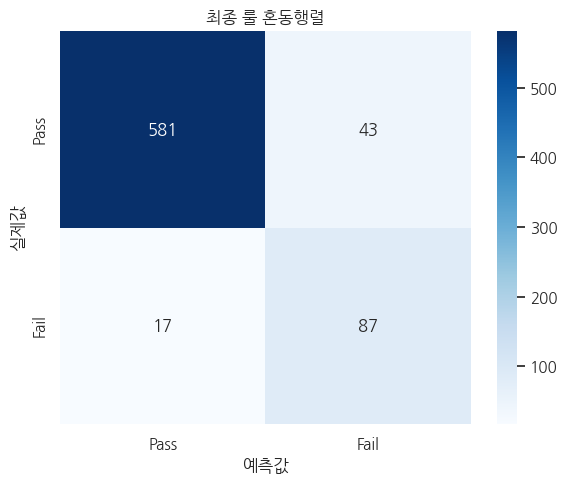


분류 리포트:
              precision    recall  f1-score   support

        Pass     0.9716    0.9311    0.9509       624
        Fail     0.6692    0.8365    0.7436       104

    accuracy                         0.9176       728
   macro avg     0.8204    0.8838    0.8472       728
weighted avg     0.9284    0.9176    0.9213       728



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 최종 룰 선택: rule1 OR rule2
# rule3는 재현율은 높이지만 정확도, 정밀도, F1을 크게 낮추므로 제외
final_rule = rule1 | rule2

# 실제값과 예측값
y_true = df['불량값']
y_pred = final_rule.astype(int)

# 혼동행렬 계산
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print('최종 룰: rule1 OR rule2')
print('rule1: metrology_cd_uniformity >= 0.040')
print('rule2: litho_focus_offset >= -0.004')

print('\n혼동행렬:')
print(cm)

# 혼동행렬 히트맵
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass', 'Fail'],
    yticklabels=['Pass', 'Fail']
)

plt.title('최종 룰 혼동행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

# 분류 리포트 출력
print('\n분류 리포트:')
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Pass', 'Fail'],
        digits=4,
        zero_division=0
    )
)

**Prompt**

혼동행렬의 네 수치와 Pass·Fail 클래스별 지표를 바탕으로 최종 룰의 활용 범위와 한계를 4문장 이내로 해석해 주세요.


**해석:** <여기 AI의 해석을 붙여넣기>

최종 룰은 TN 581, FP 43, FN 17, TP 87로, 실제 Fail 104개 중 87개를 잡아 Fail 재현율 0.8365를 확보했습니다.
Fail 정밀도는 0.6692, F1은 0.7436으로 불량 선별에 실용적인 수준이지만, Fail로 예측한 130개 중 43개가 실제 Pass여서 오탐이 존재합니다.
Pass는 정밀도 0.9716, 재현율 0.9311, F1 0.9509로 안정적으로 구분되어 정상 웨이퍼 판별에는 강한 편입니다.
따라서 이 룰은 불량 후보를 사전에 선별하는 스크리닝 용도로는 유용하지만, FP 43개와 FN 17개가 남아 있으므로 단독으로 최종 품질 판정을 내리는 기준으로 사용하기에는 한계가 있습니다.